# Package Imports

In [1]:
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

import os
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, normalize
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
import joblib
import xgboost as xgb

pd.set_option("display.max_columns", None)

seed = 42

In [2]:
current_path = os.path.abspath(os.getcwd())

# Find the index of 'slpt' in the path and keep everything up to and including 'slpt'
if "slpt" in current_path:
  base_path = current_path[:current_path.index("slpt") + len("slpt")]
else:
  base_path = current_path

# print(base_path) # ensure slpt is the last part of the path

def get_path(*args):
    """
    Returns the absolute path to a file or directory relative to the base path.
    """
    return os.path.join(base_path, *args)


# Data Import

In [3]:
data_raw = pd.read_csv(get_path("data/raw/cell2celltrain.csv"))
data_raw.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,SEAPOR503,2.0,2.0,361.0,62.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,1,0,No,No,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,PITHOM412,2.0,1.0,1504.0,40.0,42.0,Yes,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,Yes,No,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,MILMIL414,1.0,1.0,1812.0,26.0,26.0,Yes,No,No,No,No,Unknown,No,No,No,No,No,Yes,0,0,Yes,No,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,PITHOM412,9.0,4.0,458.0,30.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,Yes,No,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,OKCTUL918,4.0,3.0,852.0,46.0,54.0,No,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,Yes,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


In [4]:
data_raw.tail()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
51042,3399958,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.3,2.7,48.3,0.0,0.0,58.9,17.0,1.3,160.3,33.3,12.0,0.0,0.3,29,1,1,LAXSFN818,2.0,2.0,526.0,68.0,64.0,No,Yes,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,No,No,0,6,No,0,60,No,1-Highest,Suburban,Other,Yes
51043,3399974,No,95.17,1745.0,85.0,0.99,45.0,4.7,122.0,15.9,16.7,0.7,41.3,0.0,0.0,681.5,89.7,33.3,318.7,248.3,17.3,0.0,14.3,29,1,1,LAXCDG310,2.0,2.0,464.0,48.0,48.0,Yes,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,No,0,9,No,1,60,No,3-Good,Other,Other,No
51044,3399978,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.7,4.3,287.0,1.3,13.7,1225.3,430.3,87.7,1359.0,910.3,76.0,0.0,6.7,25,1,1,LAXCDG310,3.0,2.0,378.0,36.0,0.0,No,No,Yes,No,No,Known,No,No,No,No,No,Yes,0,0,No,No,0,7,No,1,80,No,5-Low,Other,Clerical,No
51045,3399990,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31,1,1,NEVPOW619,2.0,2.0,433.0,32.0,0.0,Yes,No,Yes,No,No,Unknown,No,No,No,No,No,No,0,0,No,No,0,9,No,0,30,No,5-Low,Other,Other,No
51046,3399994,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.7,0.7,117.3,1.3,1.0,330.9,55.0,16.7,442.3,167.3,19.3,0.0,0.0,25,1,1,NEVPOW619,7.0,5.0,75.0,0.0,0.0,No,No,Yes,No,No,Unknown,No,No,No,No,No,No,2,1,No,No,0,0,No,1,60,Yes,5-Low,Other,Other,Unknown


In [5]:
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

# Joining Data

In [6]:
# Strip the labels from credit rating and create a csv for lookup
data_raw[['CreditRatingNum', 'CreditRatingLabel']] = data_raw['CreditRating'].str.extract(r'(\d)-(.+)')
data_raw['CreditRatingNum'] = data_raw['CreditRatingNum'].astype(int)
credit_rating_lookup = data_raw[['CreditRatingNum', 'CreditRatingLabel']].drop_duplicates()
credit_rating_lookup.to_csv(get_path("data/raw/credit_rating_lookup.csv"), index=False)
data_raw = data_raw.drop(columns=['CreditRating', 'CreditRatingLabel'])

In [7]:
# Join the main data with lookup table
lookup = pd.read_csv(get_path("data/raw/credit_rating_lookup.csv"))
lookup['CreditRatingNum'] = lookup['CreditRatingNum'].astype(int)
data_joined = data_raw.merge(lookup, on='CreditRatingNum', how='left')

data_joined.head()


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,PrizmCode,Occupation,MaritalStatus,CreditRatingNum,CreditRatingLabel
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,SEAPOR503,2.0,2.0,361.0,62.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,1,0,No,No,0,4,No,0,30,Yes,Suburban,Professional,No,1,Highest
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,PITHOM412,2.0,1.0,1504.0,40.0,42.0,Yes,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,Yes,No,0,5,No,0,30,No,Suburban,Professional,Yes,4,Medium
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,MILMIL414,1.0,1.0,1812.0,26.0,26.0,Yes,No,No,No,No,Unknown,No,No,No,No,No,Yes,0,0,Yes,No,0,6,No,0,Unknown,No,Town,Crafts,Yes,3,Good
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,PITHOM412,9.0,4.0,458.0,30.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,Yes,No,0,6,No,0,10,No,Other,Other,No,4,Medium
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,OKCTUL918,4.0,3.0,852.0,46.0,54.0,No,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,Yes,0,9,No,1,10,No,Other,Professional,Yes,1,Highest


In [8]:
min_monthly_revenue = data_joined["MonthlyRevenue"].min()
max_monthly_revenue = data_joined["MonthlyRevenue"].max()
print(f"Min MonthlyRevenue: {min_monthly_revenue}")
print(f"Max MonthlyRevenue: {max_monthly_revenue}")

Min MonthlyRevenue: -6.17
Max MonthlyRevenue: 1223.38


In [9]:
data_joined.shape

(51047, 59)

In [10]:
neg_values = data_joined[data_joined["MonthlyRevenue"] < 0]
display(neg_values)
neg_values = data_joined[data_joined["TotalRecurringCharge"] < 0]
display(neg_values)
neg_values = data_joined[data_joined["CurrentEquipmentDays"] < 0]
display(neg_values)

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,PrizmCode,Occupation,MaritalStatus,CreditRatingNum,CreditRatingLabel
26596,3210322,No,-2.52,211.0,0.0,0.33,0.0,0.0,NaN,NaN,0.0,0.0,7.3,1.3,0.0,1.7,8.0,1.3,12.7,17.0,0.0,0.0,0.0,18,2,2,KCYKCK913,2.0,2.0,281.0,0.0,0.0,No,Yes,Yes,No,No,Unknown,No,No,No,No,No,No,0,0,No,No,0,0,No,0,30,No,Suburban,Other,Unknown,3,Good
33352,3265738,No,-5.86,0.0,-5.0,0.00,0.0,0.0,0.0,5.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15,3,3,NEVLVS702,1.0,1.0,452.0,34.0,0.0,No,No,Yes,No,No,Known,No,No,No,No,No,No,0,0,No,No,0,6,No,0,Unknown,No,Suburban,Other,Yes,3,Good
48038,3378298,No,-6.17,0.0,-6.0,0.00,0.0,0.0,0.0,6.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,1,1,NYCSUF516,1.0,1.0,203.0,0.0,0.0,No,Yes,Yes,No,No,Known,No,No,No,No,No,No,0,0,Yes,No,0,6,No,0,Unknown,No,Suburban,Other,No,7,Lowest


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,PrizmCode,Occupation,MaritalStatus,CreditRatingNum,CreditRatingLabel
3605,3028134,No,21.94,329.0,-2.0,0.00,44.0,6.6,-329.0,-21.9,4.3,0.0,3.7,0.7,0.0,8.0,1.7,0.0,1.0,10.3,4.3,0.0,0.0,33,1,1,HARNEW203,4.0,2.0,596.0,30.0,32.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,Yes,No,0,7,No,1,30,No,Suburban,Other,Yes,1,Highest
18432,3144294,No,19.93,279.0,-2.0,0.00,90.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17,1,1,LAXSAN714,3.0,2.0,290.0,0.0,0.0,No,Yes,Yes,No,No,Unknown,No,No,No,No,No,No,0,0,No,No,0,0,No,0,30,No,Other,Other,Unknown,5,Low
23904,3188158,Yes,94.77,908.0,-6.0,4.95,4.0,0.0,-908.0,-89.8,5.7,1.3,21.7,3.0,0.3,107.0,22.3,5.0,71.0,51.7,7.0,0.0,4.0,16,3,2,SFRSFR415,2.0,2.0,119.0,0.0,0.0,No,Yes,Yes,No,No,Unknown,No,No,No,No,No,No,0,0,Yes,No,0,0,No,0,150,No,Suburban,Other,Unknown,5,Low
30764,3244958,No,34.62,0.0,-9.0,0.00,0.0,0.0,NaN,NaN,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,14,2,2,NYCBRO917,1.0,1.0,422.0,0.0,0.0,No,No,Yes,No,No,Unknown,No,No,No,No,No,No,0,0,No,No,0,0,No,0,Unknown,No,Other,Other,Unknown,5,Low
33352,3265738,No,-5.86,0.0,-5.0,0.00,0.0,0.0,0.0,5.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15,3,3,NEVLVS702,1.0,1.0,452.0,34.0,0.0,No,No,Yes,No,No,Known,No,No,No,No,No,No,0,0,No,No,0,6,No,0,Unknown,No,Suburban,Other,Yes,3,Good
35304,3281886,No,3.56,157.0,-1.0,0.00,7.0,0.6,-157.0,-3.6,1.0,0.0,4.3,10.7,0.0,69.9,13.0,0.7,25.7,25.7,1.0,0.0,0.0,12,1,1,BOSBOS978,1.0,1.0,363.0,40.0,72.0,No,No,Yes,No,No,Known,No,No,No,No,No,Yes,0,0,No,No,0,3,No,0,Unknown,No,Town,Other,Unknown,4,Medium
42186,3335626,Yes,37.24,0.0,-11.0,0.00,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,1,1,MINSTP612,2.0,2.0,3.0,0.0,0.0,No,No,Yes,No,No,Unknown,No,No,No,No,No,No,0,0,No,No,0,0,No,0,80,No,Suburban,Other,Unknown,6,VeryLow
48038,3378298,No,-6.17,0.0,-6.0,0.00,0.0,0.0,0.0,6.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,1,1,NYCSUF516,1.0,1.0,203.0,0.0,0.0,No,Yes,Yes,No,No,Known,No,No,No,No,No,No,0,0,Yes,No,0,6,No,0,Unknown,No,Suburban,Other,No,7,Lowest


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,PrizmCode,Occupation,MaritalStatus,CreditRatingNum,CreditRatingLabel
107,3000762,Yes,180.22,3559.0,150.0,11.38,99.0,0.0,-149.0,-11.4,3.7,31.0,120.7,0.0,0.3,1543.7,26.7,6.7,725.3,468.7,34.7,0.0,60.7,55,3,2,OKCLRK501,10.0,5.0,-3.0,0.0,0.0,No,Yes,Yes,No,No,Unknown,No,No,No,No,No,No,0,0,No,Yes,0,0,No,0,150,No,Other,Other,Unknown,3,Good
424,3003242,No,36.34,247.0,30.0,2.48,7.0,1.0,154.0,14.1,2.7,0.7,21.3,0.0,0.0,14.0,22.7,3.7,68.0,25.0,3.3,0.0,0.0,52,1,1,SEASEA206,4.0,4.0,-1.0,62.0,54.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,1,1,No,No,0,6,No,0,10,Yes,Town,Self,Yes,1,Highest
2107,3016538,No,95.35,1254.0,85.0,0.00,29.0,0.0,-380.0,-14.1,14.3,0.0,25.3,3.3,0.0,660.4,32.3,14.7,316.0,121.7,14.3,0.0,3.0,40,2,2,NYCSUF516,5.0,4.0,-3.0,46.0,42.0,Yes,No,Yes,Yes,Yes,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,No,0,6,No,0,80,No,Other,Self,Yes,1,Highest
2145,3016766,No,88.98,1.0,50.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40,1,1,SANCRP512,4.0,3.0,-1.0,60.0,30.0,Yes,No,Yes,Yes,Yes,Known,Yes,Yes,No,No,No,Yes,0,0,No,No,0,6,No,2,10,No,Other,Professional,Unknown,6,VeryLow
3883,3030326,No,62.17,839.0,81.0,0.25,0.0,0.0,138.0,-3.5,4.7,5.0,46.0,3.0,0.3,245.4,21.7,4.3,245.0,86.3,9.7,0.0,9.0,37,2,1,MIANDA305,8.0,7.0,-3.0,0.0,0.0,No,No,Yes,No,No,Unknown,No,No,No,No,No,No,0,0,Yes,No,0,0,No,2,80,No,Other,Other,Unknown,1,Highest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48923,3384342,No,31.20,682.0,35.0,0.74,0.0,0.0,205.0,-6.8,8.0,1.0,40.7,12.0,0.0,49.2,21.7,1.3,96.0,54.7,9.0,0.0,0.0,8,1,1,NEVCHU619,2.0,2.0,-3.0,0.0,0.0,No,No,Yes,No,No,Unknown,No,No,No,No,No,No,0,0,No,Yes,0,0,No,0,150,No,Other,Other,Unknown,4,Medium
49160,3385954,No,64.19,490.0,37.0,2.97,70.0,0.9,-80.0,-6.4,1.7,0.7,20.7,0.0,0.7,63.0,20.3,9.0,67.7,48.7,2.3,0.0,1.0,7,1,1,SANSAN210,2.0,2.0,-3.0,0.0,0.0,No,No,Yes,No,No,Unknown,No,No,No,No,No,No,0,0,Yes,No,0,0,No,0,150,No,Suburban,Other,Unknown,4,Medium
49441,3387894,No,52.27,719.0,50.0,0.00,21.0,0.0,137.0,13.7,27.3,3.0,169.0,2.0,2.7,114.9,11.3,3.3,144.0,189.3,30.3,0.0,0.0,7,1,1,NYCBRO917,2.0,2.0,-2.0,0.0,0.0,No,Yes,No,No,No,Unknown,No,No,No,No,No,No,0,0,Yes,No,0,0,No,0,130,No,Other,Other,Unknown,5,Low
49530,3388482,No,55.66,1309.0,50.0,0.00,43.0,0.5,-267.0,-15.7,9.7,8.7,36.3,3.3,0.0,302.4,52.0,7.3,111.0,167.0,18.3,0.0,5.3,7,1,1,APCFCH703,2.0,2.0,-1.0,0.0,0.0,No,Yes,Yes,No,No,Unknown,No,No,No,No,No,No,0,0,Yes,No,0,0,No,0,100,No,Other,Other,Unknown,5,Low


# Cleaning Data

In [11]:
# Check for missing values in columns
missing = data_joined.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

AgeHH1                   909
AgeHH2                   909
PercChangeMinutes        367
PercChangeRevenues       367
MonthlyRevenue           156
MonthlyMinutes           156
TotalRecurringCharge     156
DirectorAssistedCalls    156
OverageMinutes           156
RoamingCalls             156
ServiceArea               24
Handsets                   1
HandsetModels              1
CurrentEquipmentDays       1
dtype: int64

In [12]:
data_joined.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,PrizmCode,Occupation,MaritalStatus,CreditRatingNum,CreditRatingLabel
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,SEAPOR503,2.0,2.0,361.0,62.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,1,0,No,No,0,4,No,0,30,Yes,Suburban,Professional,No,1,Highest
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,PITHOM412,2.0,1.0,1504.0,40.0,42.0,Yes,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,Yes,No,0,5,No,0,30,No,Suburban,Professional,Yes,4,Medium
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,MILMIL414,1.0,1.0,1812.0,26.0,26.0,Yes,No,No,No,No,Unknown,No,No,No,No,No,Yes,0,0,Yes,No,0,6,No,0,Unknown,No,Town,Crafts,Yes,3,Good
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,PITHOM412,9.0,4.0,458.0,30.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,Yes,No,0,6,No,0,10,No,Other,Other,No,4,Medium
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,OKCTUL918,4.0,3.0,852.0,46.0,54.0,No,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,Yes,0,9,No,1,10,No,Other,Professional,Yes,1,Highest


In [13]:
data_joined.tail()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,PrizmCode,Occupation,MaritalStatus,CreditRatingNum,CreditRatingLabel
51042,3399958,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.3,2.7,48.3,0.0,0.0,58.9,17.0,1.3,160.3,33.3,12.0,0.0,0.3,29,1,1,LAXSFN818,2.0,2.0,526.0,68.0,64.0,No,Yes,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,No,No,0,6,No,0,60,No,Suburban,Other,Yes,1,Highest
51043,3399974,No,95.17,1745.0,85.0,0.99,45.0,4.7,122.0,15.9,16.7,0.7,41.3,0.0,0.0,681.5,89.7,33.3,318.7,248.3,17.3,0.0,14.3,29,1,1,LAXCDG310,2.0,2.0,464.0,48.0,48.0,Yes,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,No,0,9,No,1,60,No,Other,Other,No,3,Good
51044,3399978,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.7,4.3,287.0,1.3,13.7,1225.3,430.3,87.7,1359.0,910.3,76.0,0.0,6.7,25,1,1,LAXCDG310,3.0,2.0,378.0,36.0,0.0,No,No,Yes,No,No,Known,No,No,No,No,No,Yes,0,0,No,No,0,7,No,1,80,No,Other,Clerical,No,5,Low
51045,3399990,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31,1,1,NEVPOW619,2.0,2.0,433.0,32.0,0.0,Yes,No,Yes,No,No,Unknown,No,No,No,No,No,No,0,0,No,No,0,9,No,0,30,No,Other,Other,No,5,Low
51046,3399994,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.7,0.7,117.3,1.3,1.0,330.9,55.0,16.7,442.3,167.3,19.3,0.0,0.0,25,1,1,NEVPOW619,7.0,5.0,75.0,0.0,0.0,No,No,Yes,No,No,Unknown,No,No,No,No,No,No,2,1,No,No,0,0,No,1,60,Yes,Other,Other,Unknown,5,Low


In [14]:
data_joined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 59 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

In [15]:
# Drop AgeHH1 and AgeHH2 due to missing values
data_joined.drop(columns=["AgeHH1", "AgeHH2"], inplace=True)

# Fill missing values in crtical columns with average values
usage_cols = ["MonthlyRevenue", "MonthlyMinutes", "TotalRecurringCharge", "DirectorAssistedCalls", "OverageMinutes", "RoamingCalls"]
for col in usage_cols:
    data_joined[col].fillna(data_joined[col].median(), inplace=True)

# Fill missing new & inactive customer data with 0
data_joined["PercChangeMinutes"].fillna(0, inplace=True)
data_joined["PercChangeRevenues"].fillna(0, inplace=True)

# Fill other missing data
data_joined["ServiceArea"].fillna(data_joined["ServiceArea"].mode()[0], inplace=True)
data_joined["Handsets"].fillna(data_joined["Handsets"].median(), inplace=True)
data_joined["HandsetModels"].fillna(data_joined["HandsetModels"].median(), inplace=True)
data_joined["CurrentEquipmentDays"].fillna(data_joined["CurrentEquipmentDays"].median(), inplace=True)

# Descriptive Statistics

In [16]:
numeric_cols = data_joined.select_dtypes(include='number')
if 'CustomerID' in numeric_cols.columns:
    numeric_cols = numeric_cols.drop(columns=['CustomerID'])
numeric_cols.describe()

,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,Handsets,HandsetModels,CurrentEquipmentDays,RetentionCalls,RetentionOffersAccepted,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating,CreditRatingNum
count,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000
mean,58.802788,525.165514,46.824495,0.893257,39.914628,1.232466,-11.464885,-1.183415,6.011489,4.085672,28.288981,1.868999,0.298838,114.800121,25.377715,8.178104,90.549515,67.650790,10.158003,0.012277,1.840504,18.756264,1.532157,1.354340,1.805630,1.558740,380.544831,0.037201,0.018277,0.052070,4.324524,0.053911,2.886967
std,44.442964,529.134170,23.812615,2.225423,96.462028,9.803517,256.589244,39.432523,9.043955,10.946905,38.876194,5.096138,1.168277,166.485896,35.209147,16.665878,104.947470,92.752699,15.555284,0.594168,5.585129,9.800138,1.223384,0.675477,1.331165,0.905927,253.799599,0.206483,0.142458,0.307592,3.138236,0.383147,1.583360
min,-6.170000,0.000000,-11.000000,0.000000,0.000000,0.000000,-3875.000000,-1107.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,1.000000,0.000000,1.000000,1.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,33.660000,159.000000,30.000000,0.000000,0.000000,0.000000,-82.000000,-6.900000,0.700000,0.000000,5.300000,0.000000,0.000000,8.300000,3.300000,0.000000,23.000000,11.000000,1.700000,0.000000,0.000000,11.000000,1.000000,1.000000,1.000000,1.000000,205.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,48.460000,366.000000,45.000000,0.250000,3.000000,0.000000,-4.000000,-0.300000,3.000000,1.000000,16.300000,0.000000,0.000000,52.800000,13.700000,2.000000,62.000000,35.700000,5.300000,0.000000,0.300000,16.000000,1.000000,1.000000,1.000000,1.000000,329.000000,0.000000,0.000000,0.000000,5.000000,0.000000,2.000000
75%,70.960000,722.000000,60.000000,0.990000,40.000000,0.200000,65.000000,1.550000,7.700000,3.700000,36.300000,1.700000,0.300000,153.500000,34.000000,9.300000,121.300000,88.700000,12.300000,0.000000,1.300000,24.000000,2.000000,2.000000,2.000000,2.000000,515.000000,0.000000,0.000000,0.000000,7.000000,0.000000,4.000000
max,1223.380000,7359.000000,400.000000,159.390000,4321.000000,1112.400000,5192.000000,2483.500000,221.700000,384.300000,848.700000,327.300000,66.000000,2692.400000,644.300000,519.300000,2090.700000,1474.700000,411.700000,81.300000,212.700000,61.000000,196.000000,53.000000,24.000000,15.000000,1812.000000,4.000000,3.000000,35.000000,9.000000,25.000000,7.000000


# Visualisations

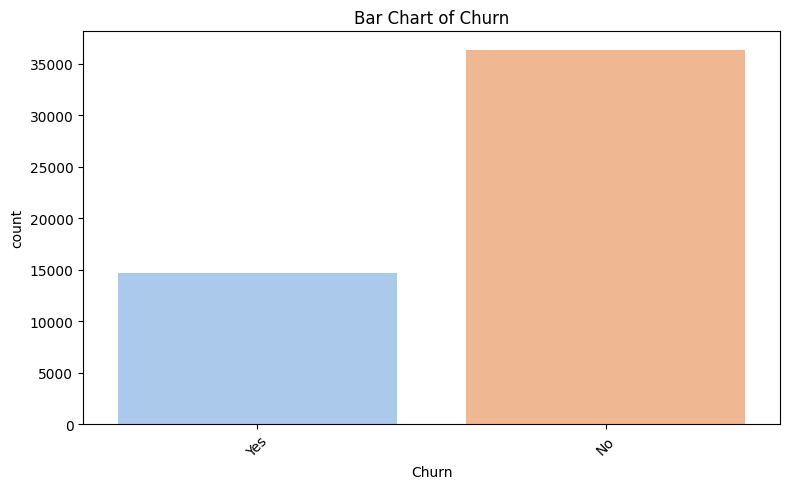

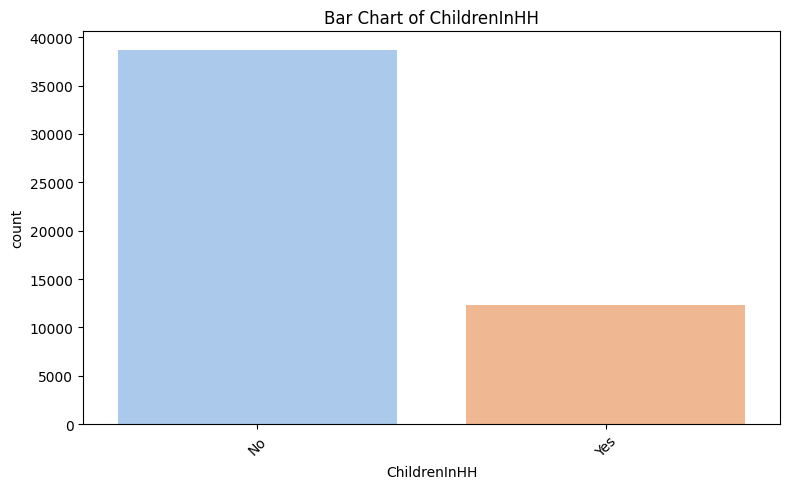

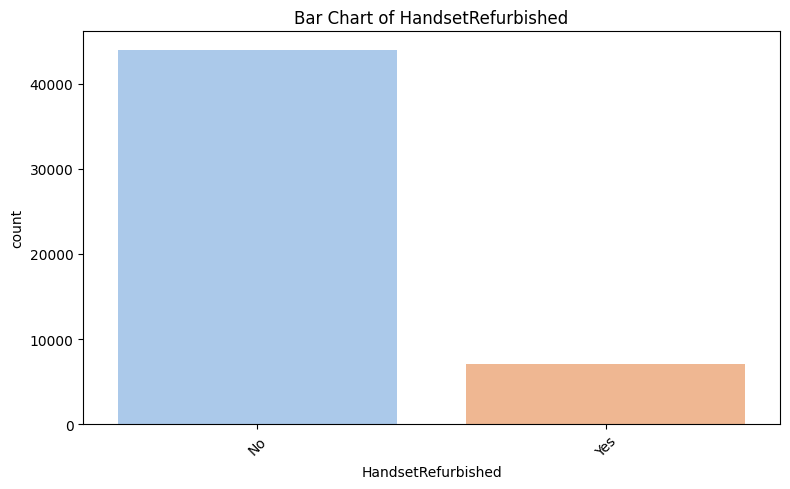

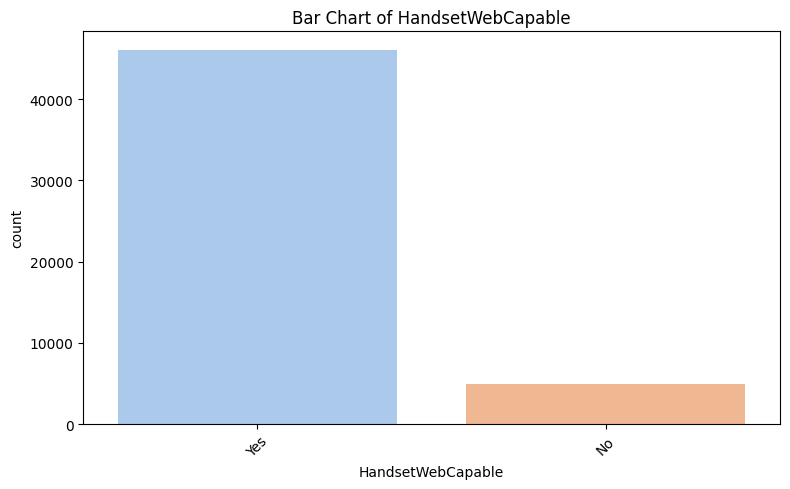

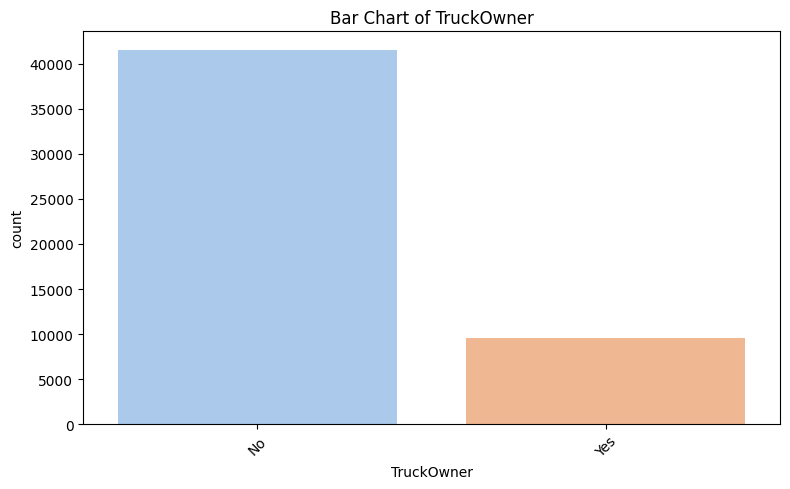

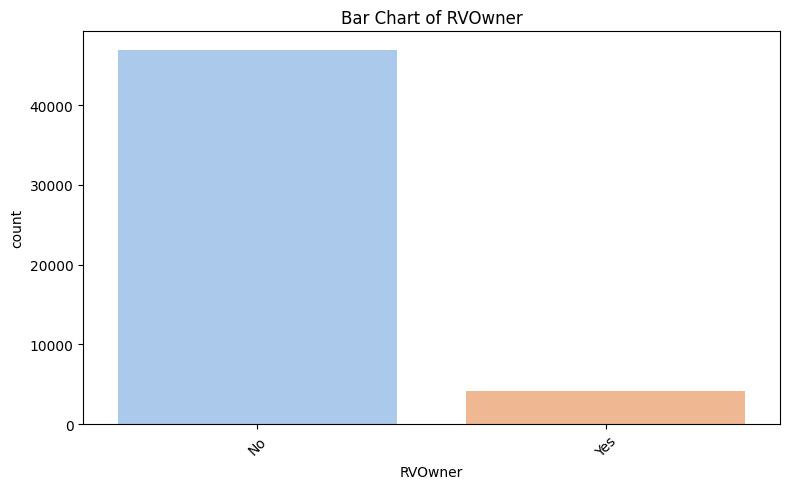

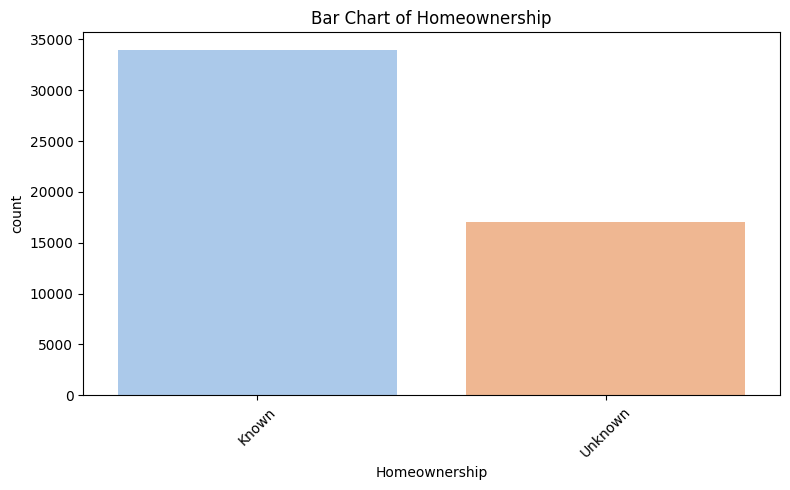

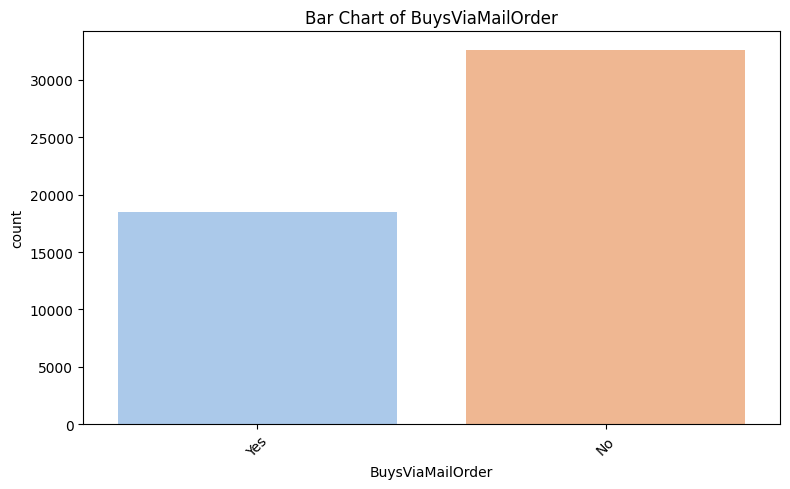

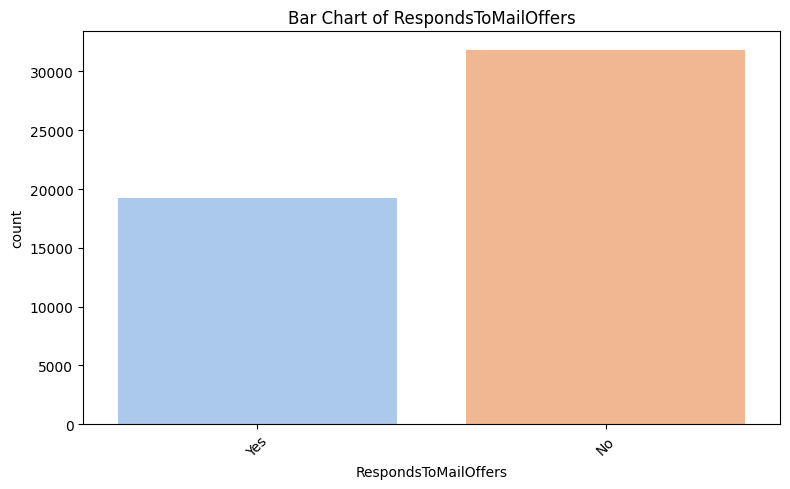

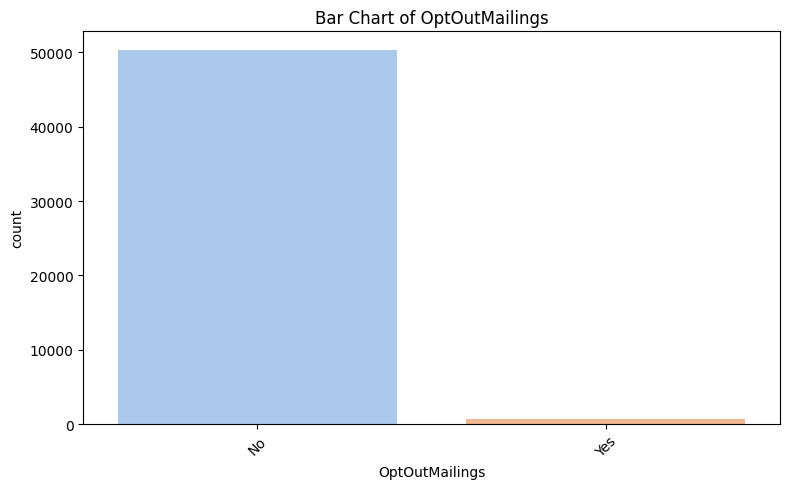

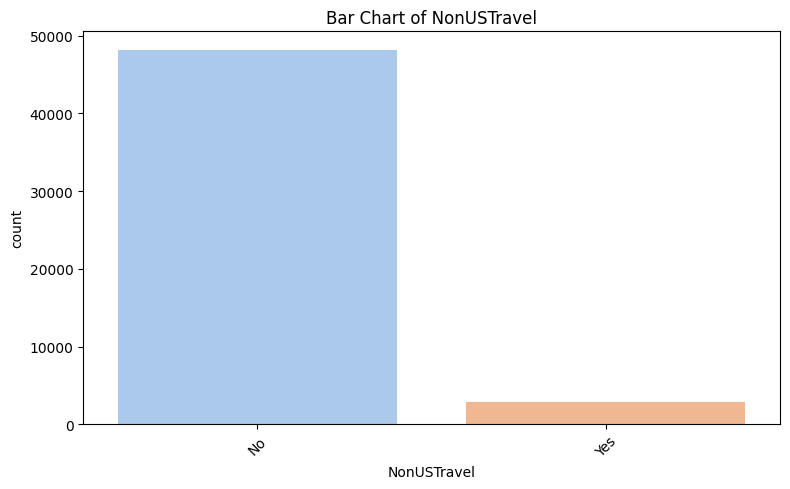

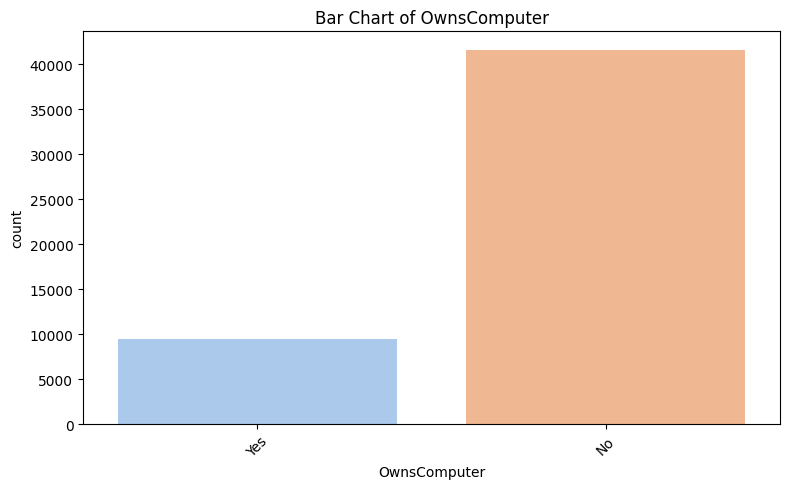

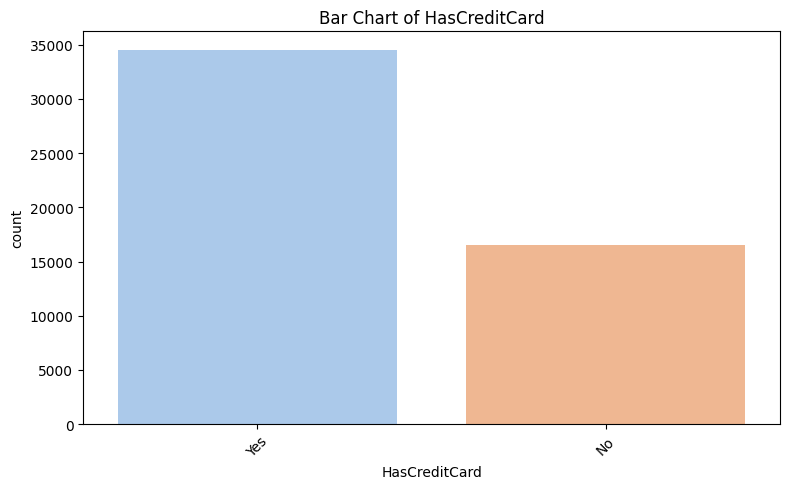

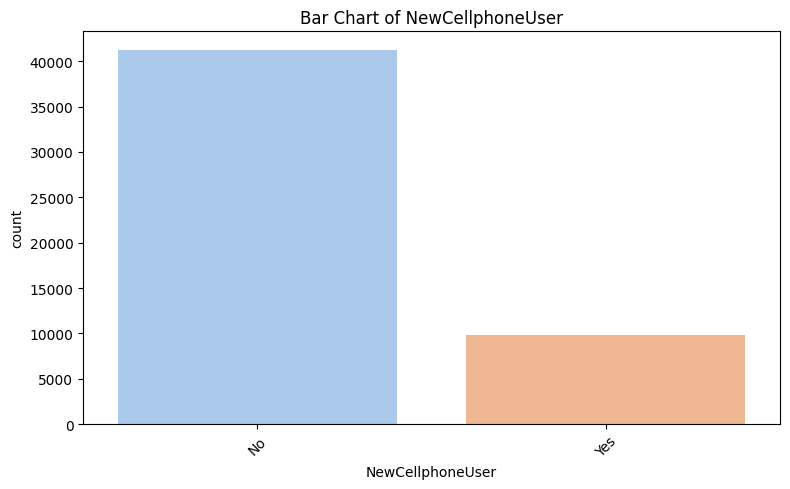

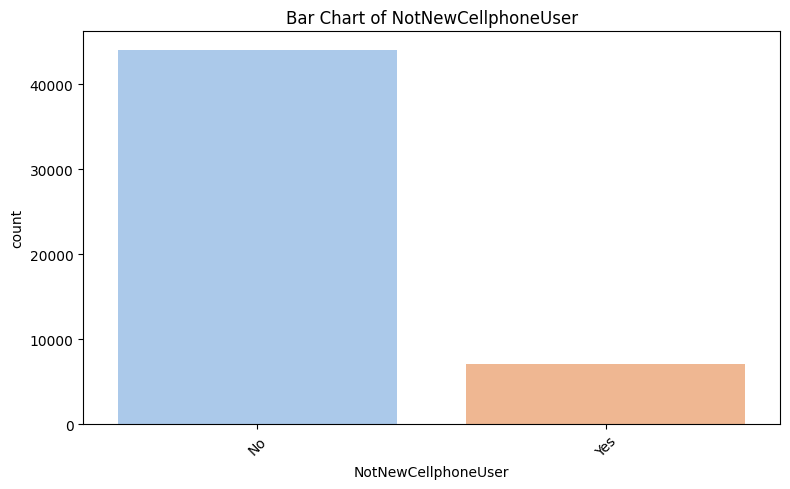

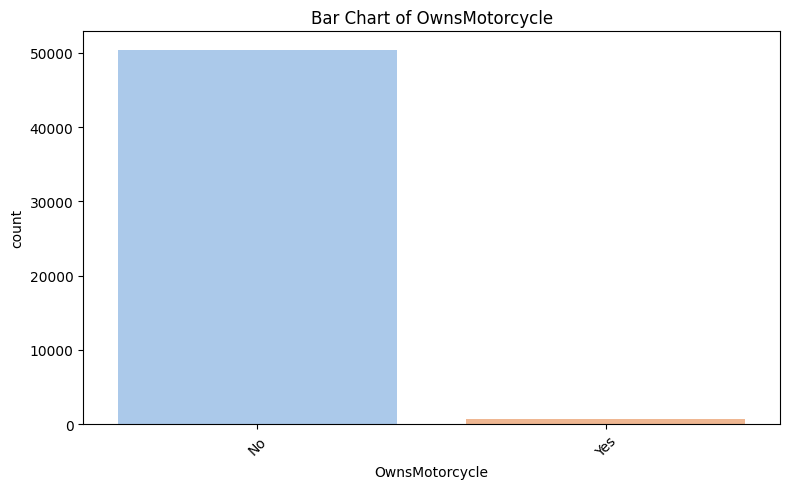

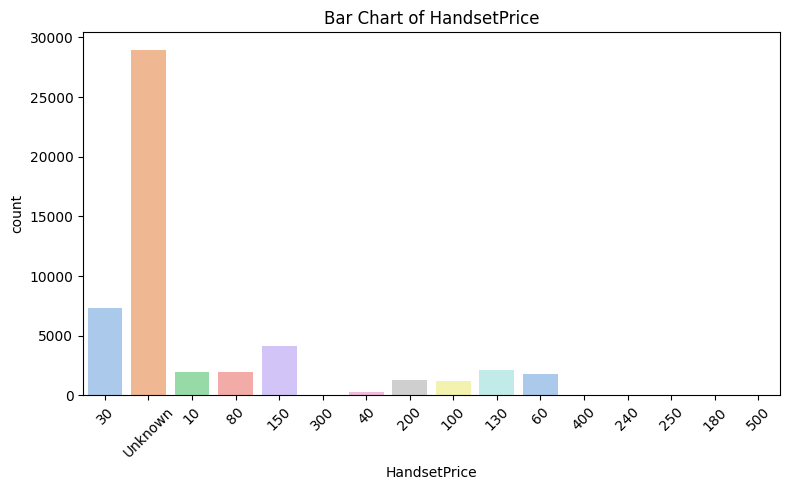

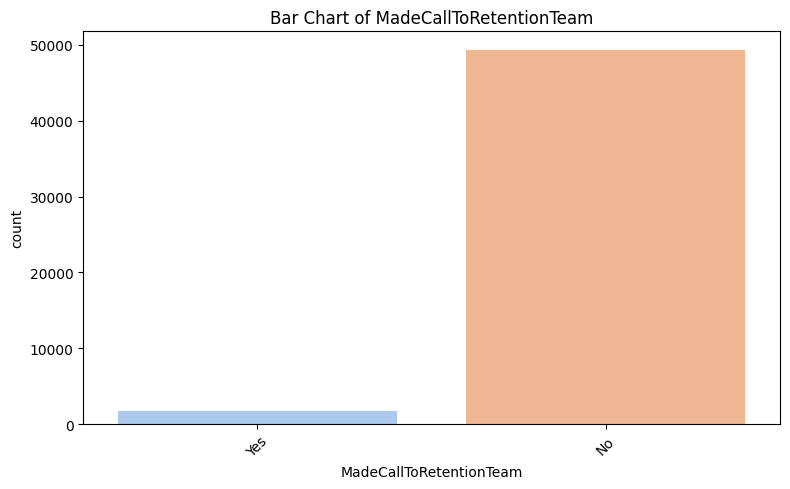

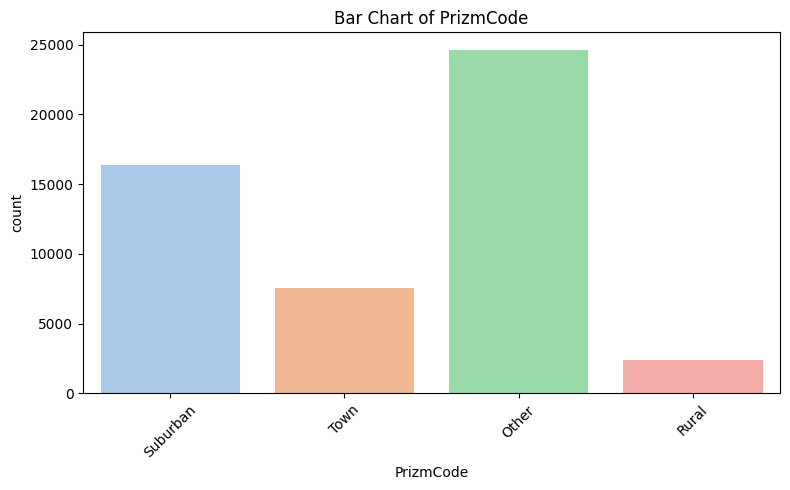

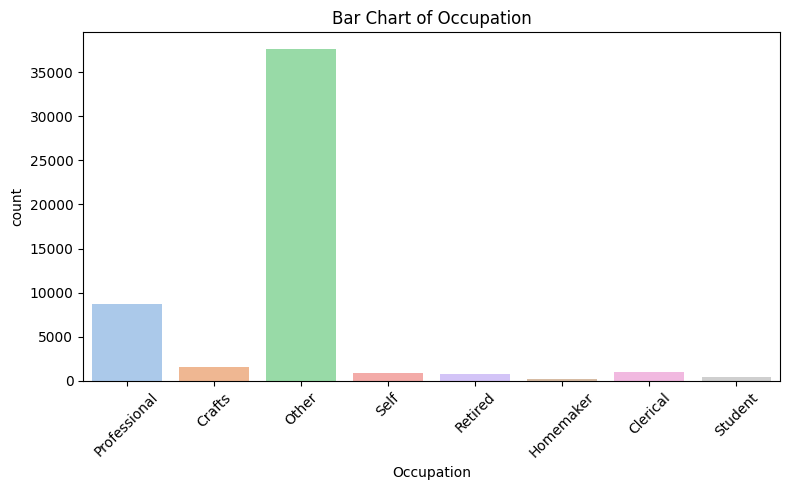

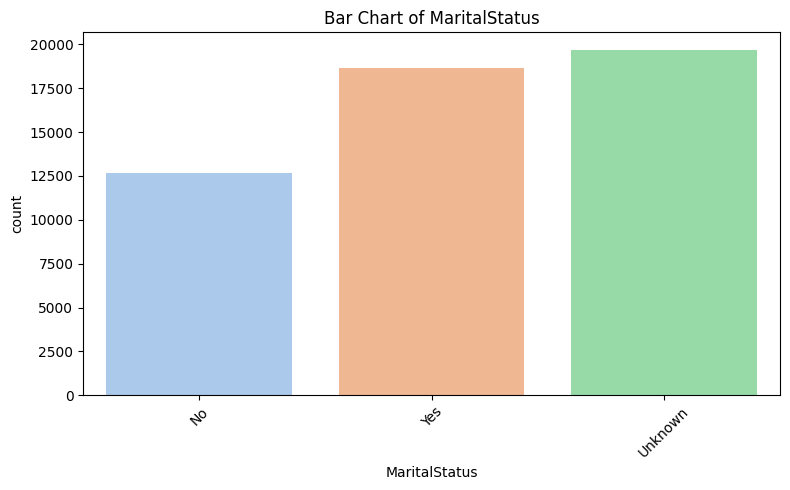

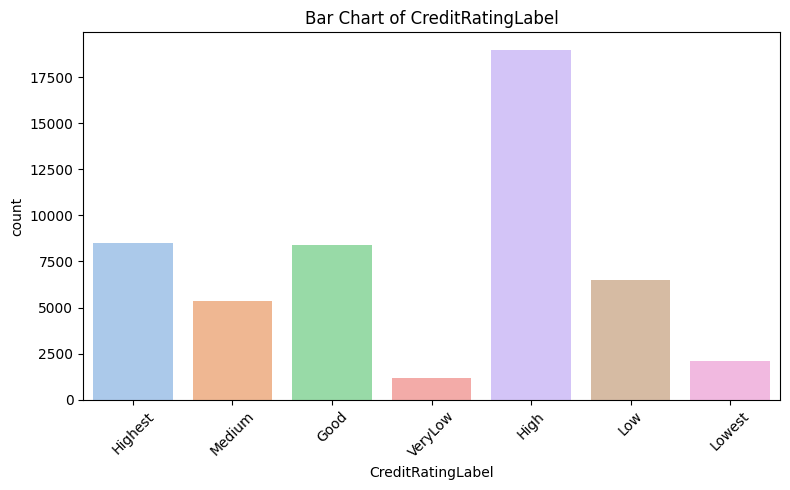

In [17]:
# Select only categorical columns (object or category types)
cat_cols = data_joined.select_dtypes(include=['object', 'category'])
if 'ServiceArea' in cat_cols.columns:
    cat_cols = cat_cols.drop(columns=['ServiceArea'])
# Plot bar charts for each categorical column
for col in cat_cols.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=data_joined, x=col, palette='pastel')
    plt.title(f'Bar Chart of {col}')
    plt.xticks(rotation=45)  # Rotate labels if needed
    plt.tight_layout()
    plt.show()

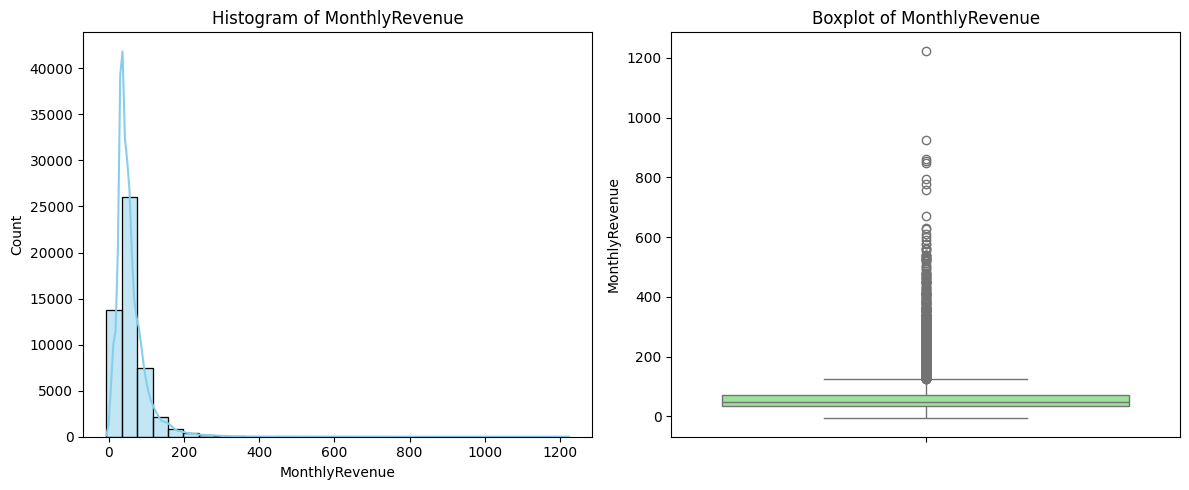

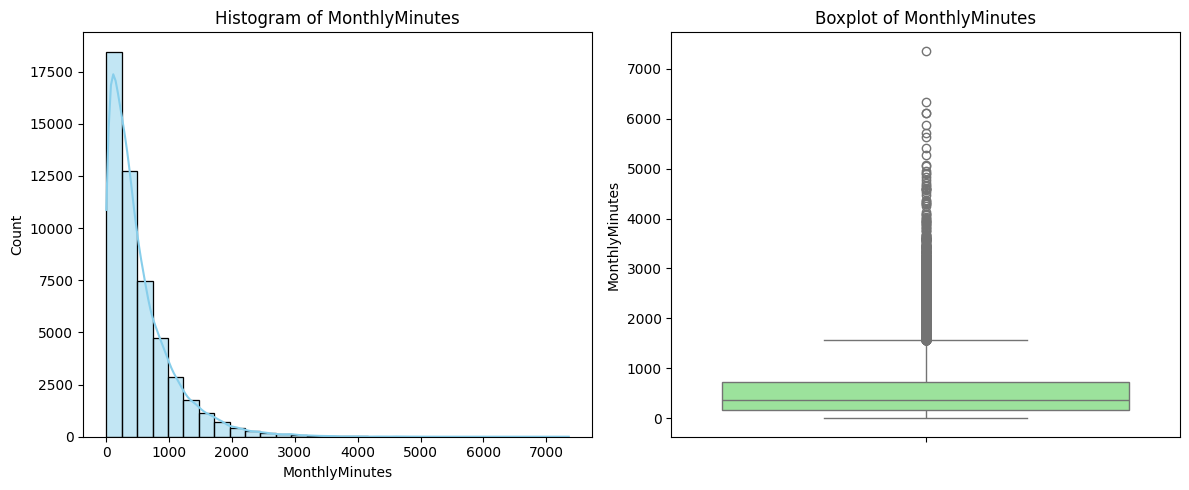

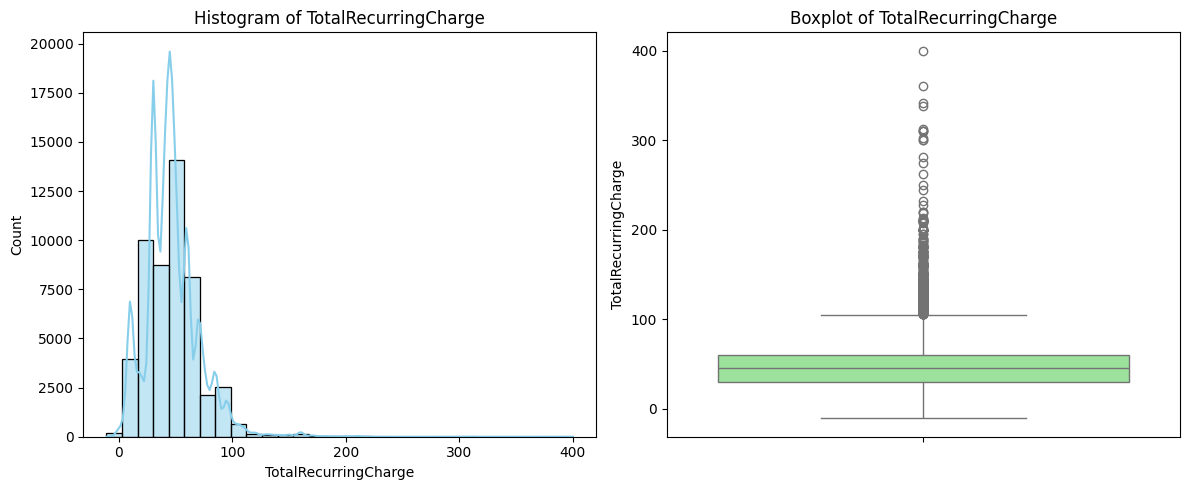

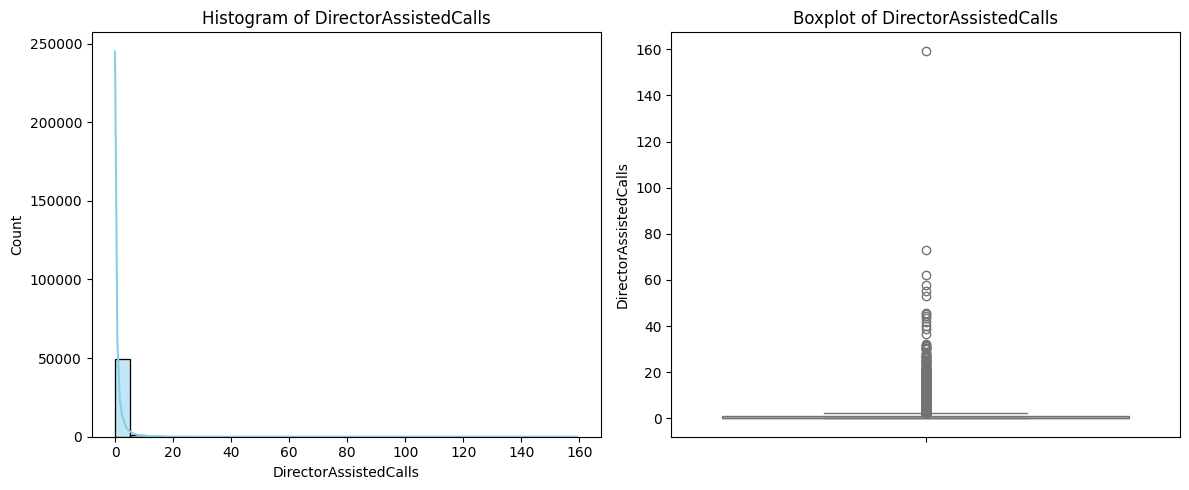

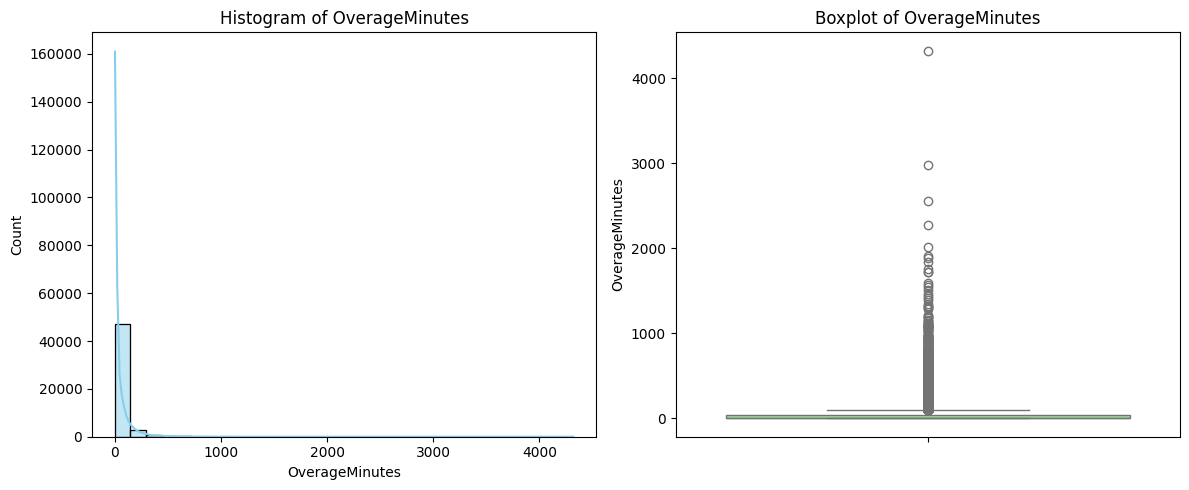

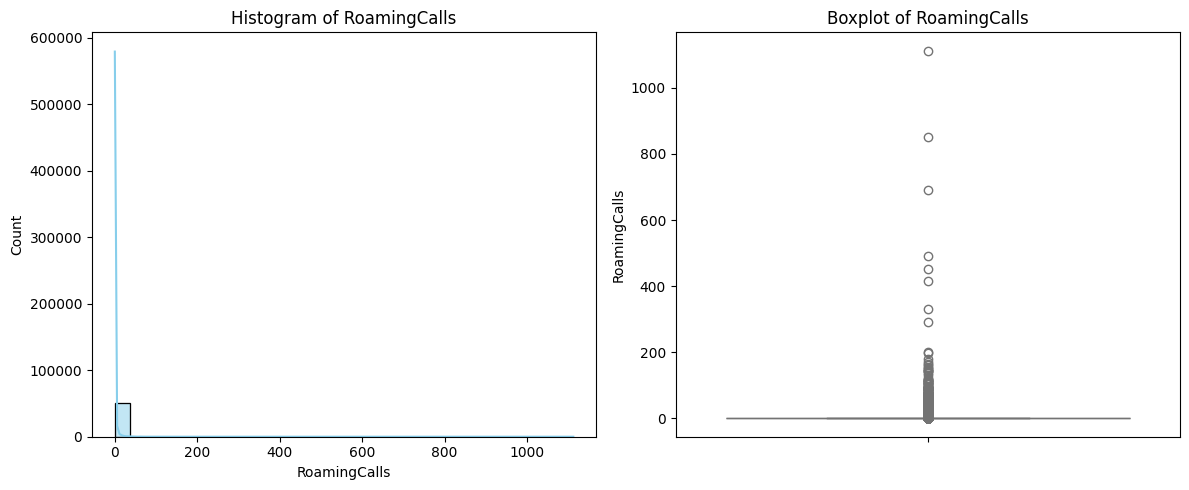

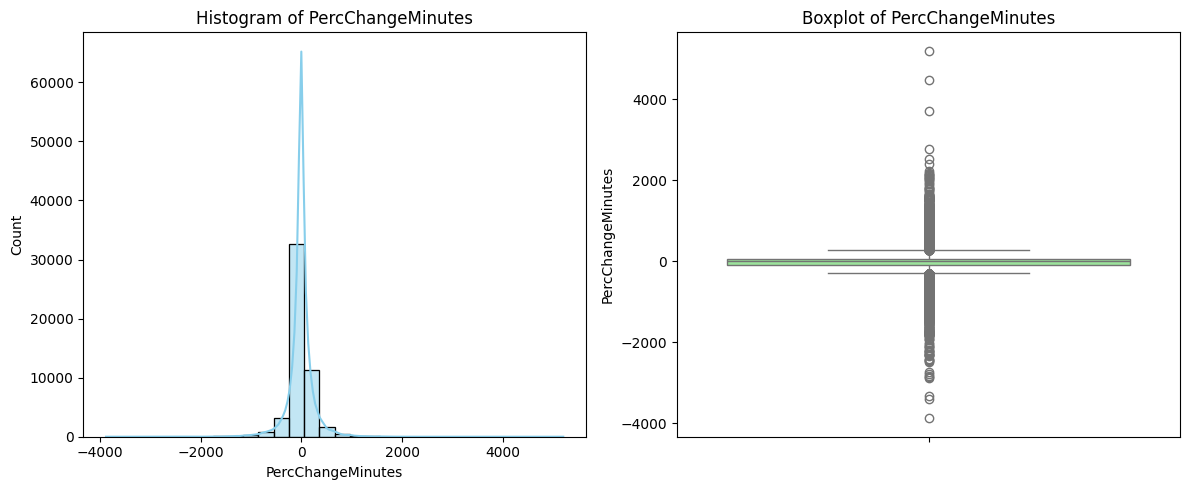

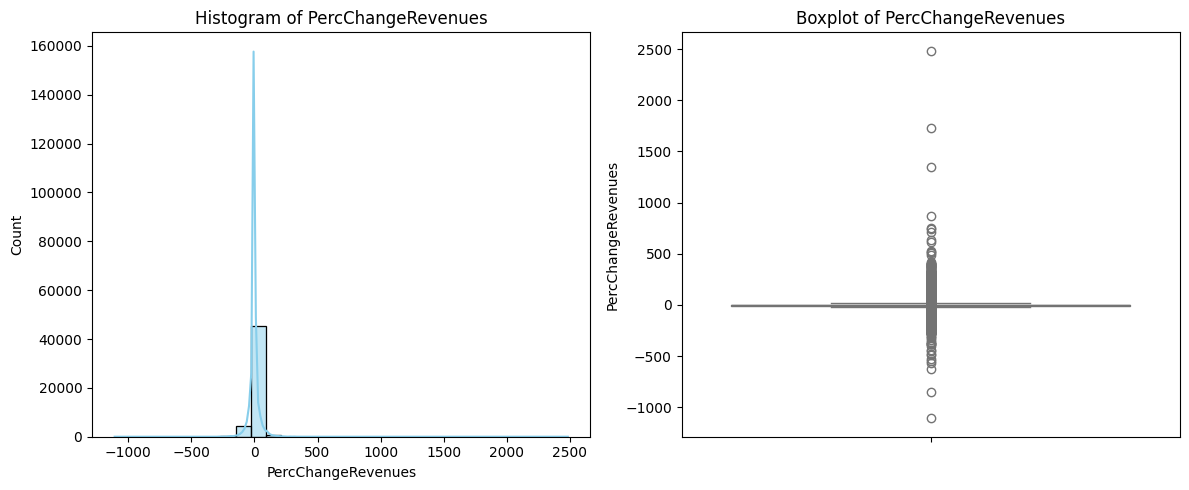

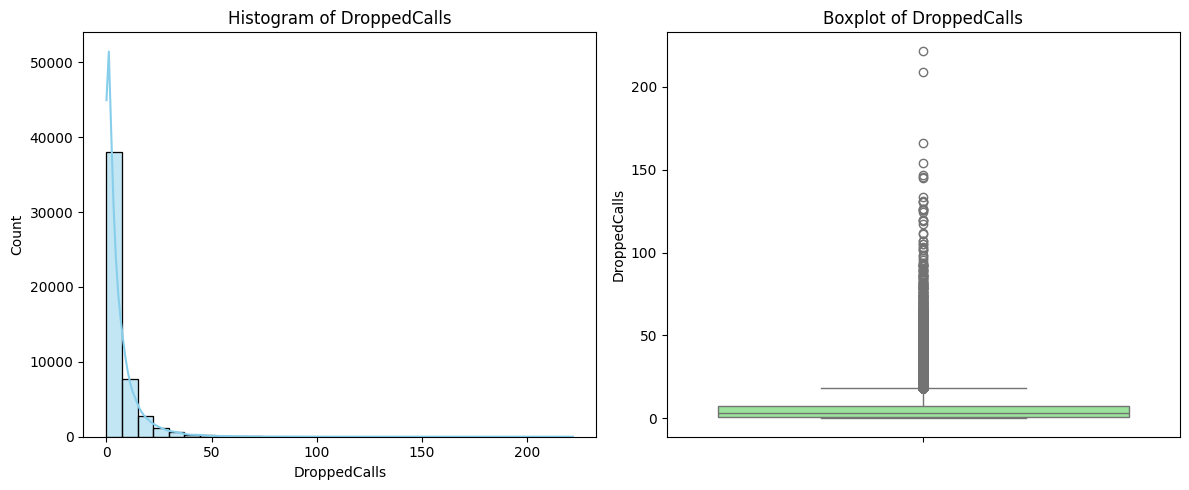

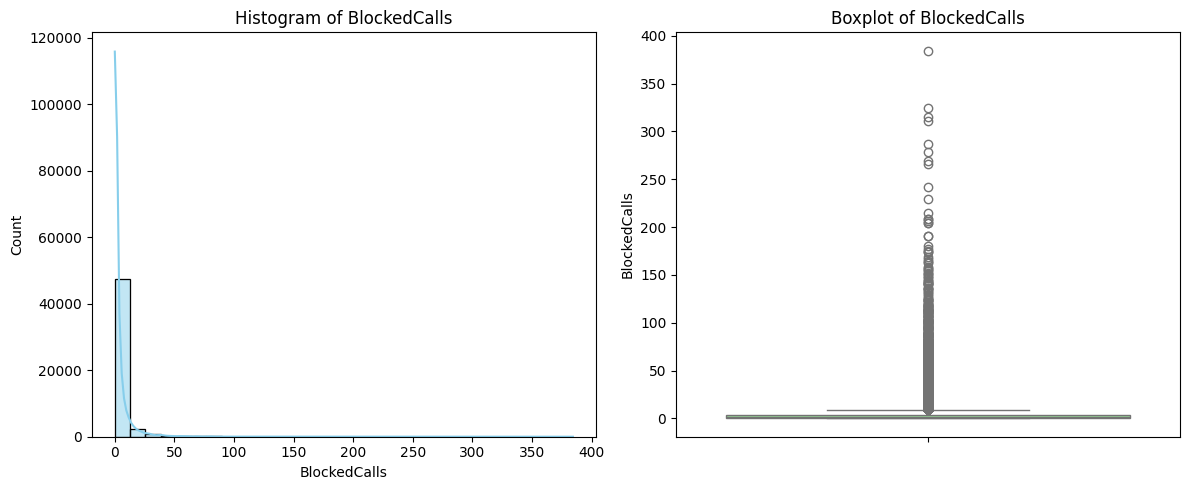

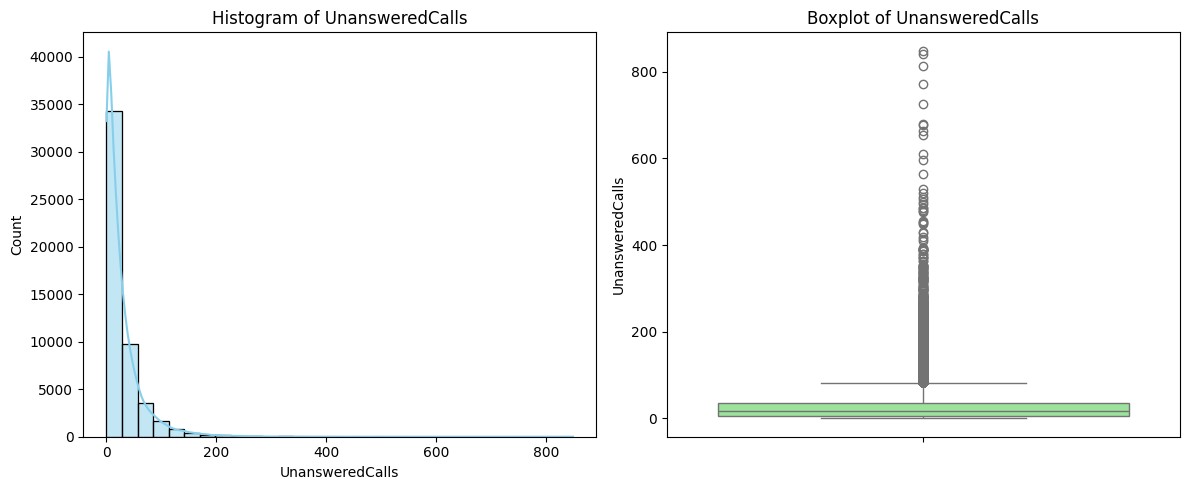

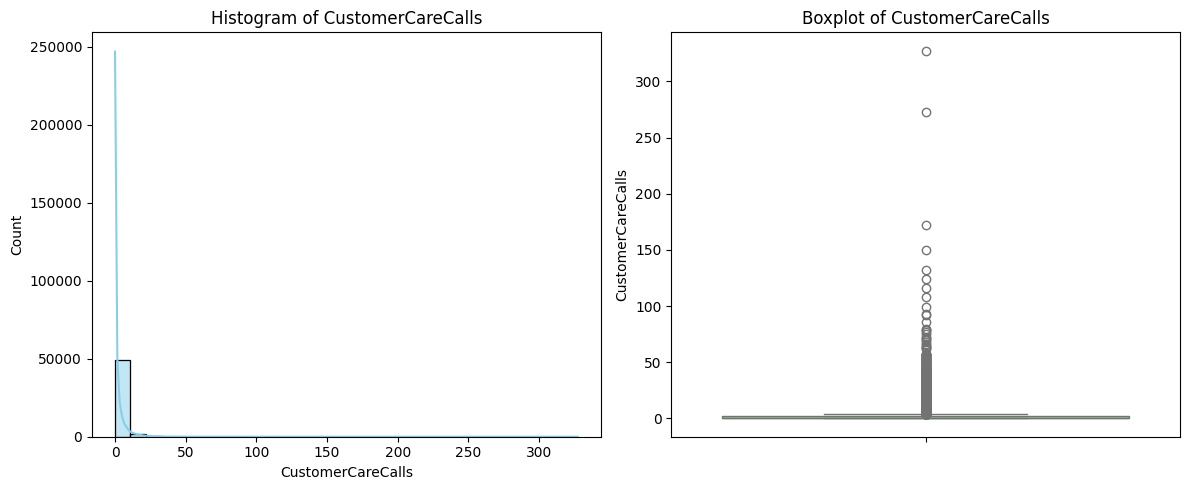

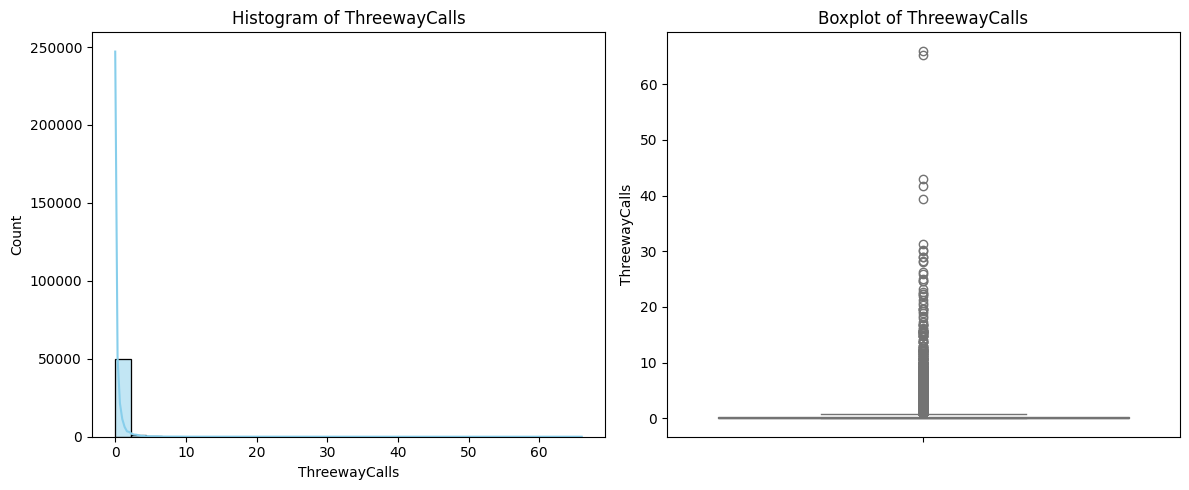

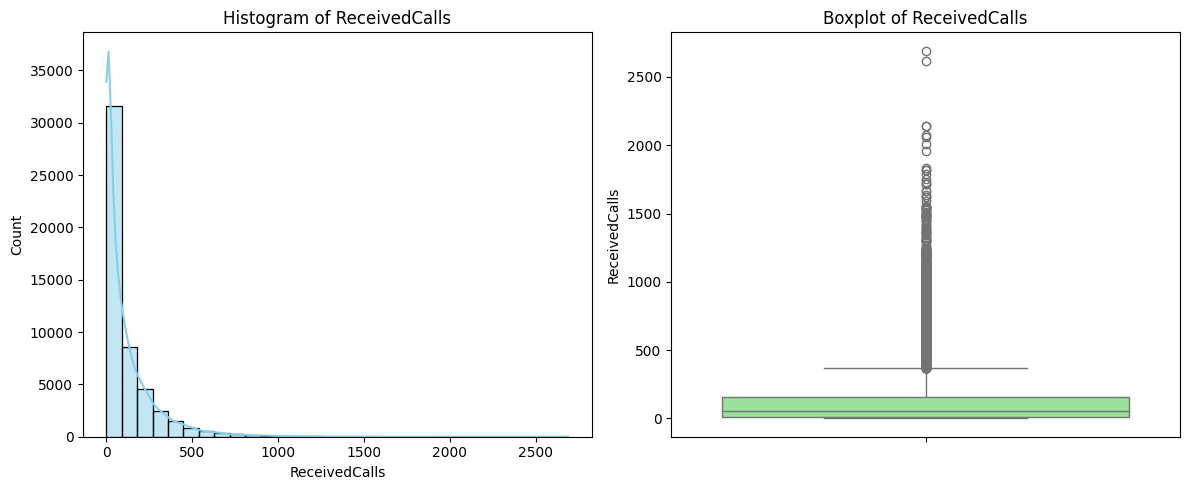

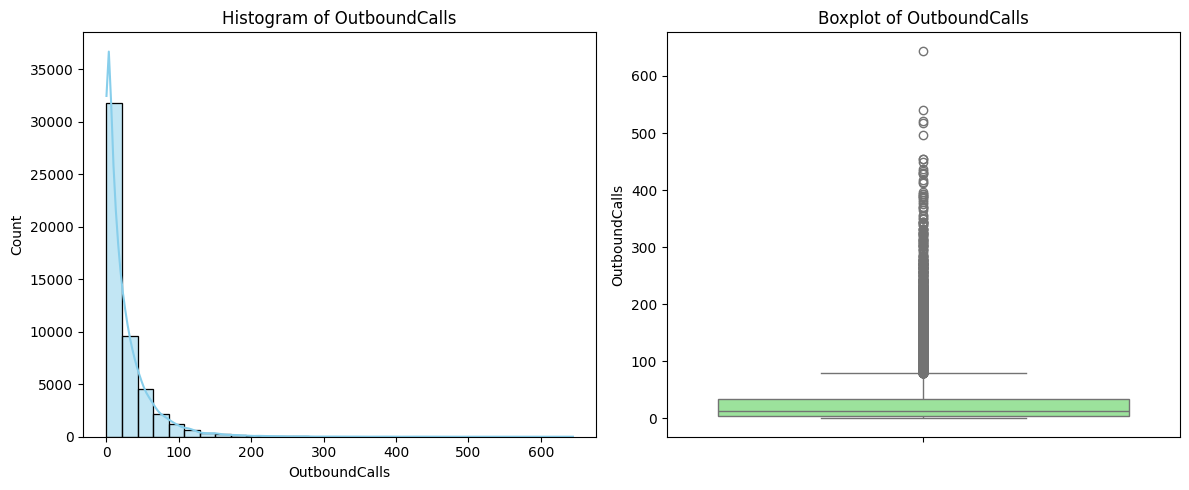

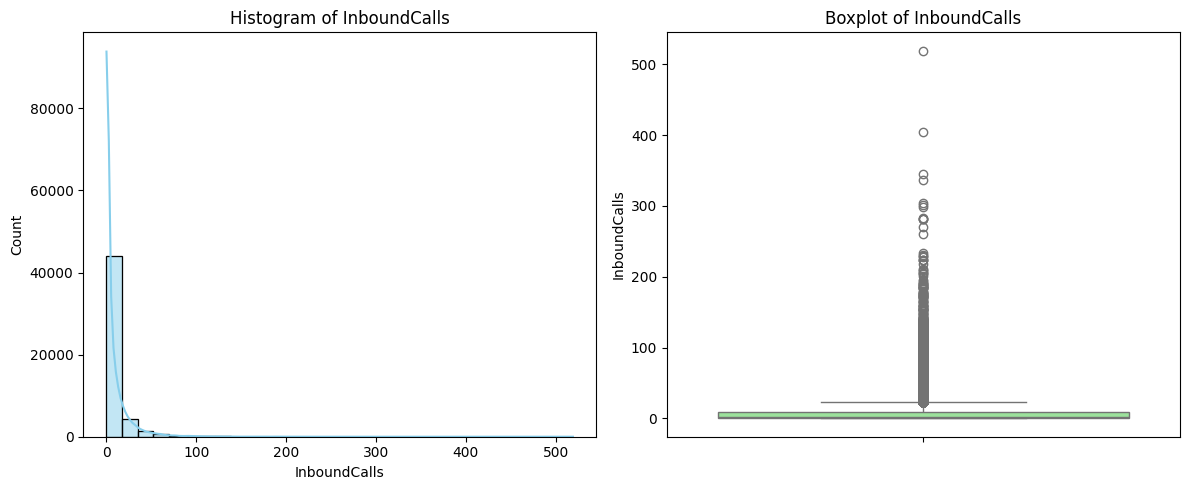

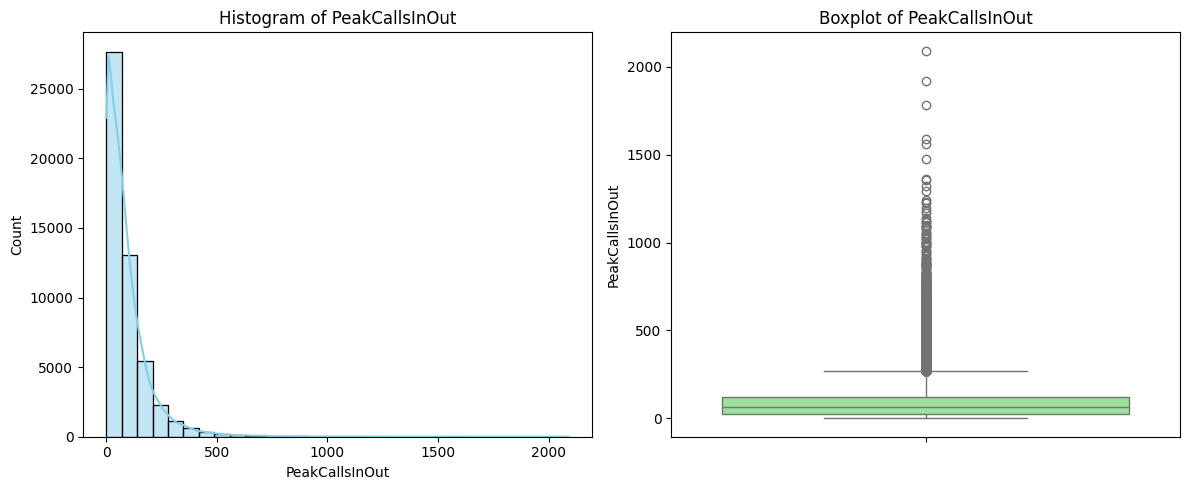

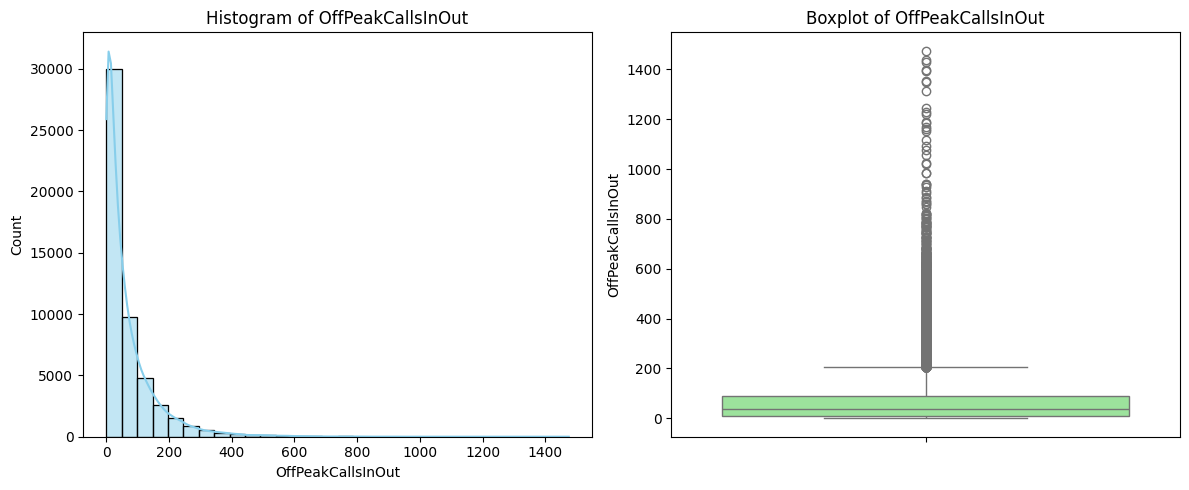

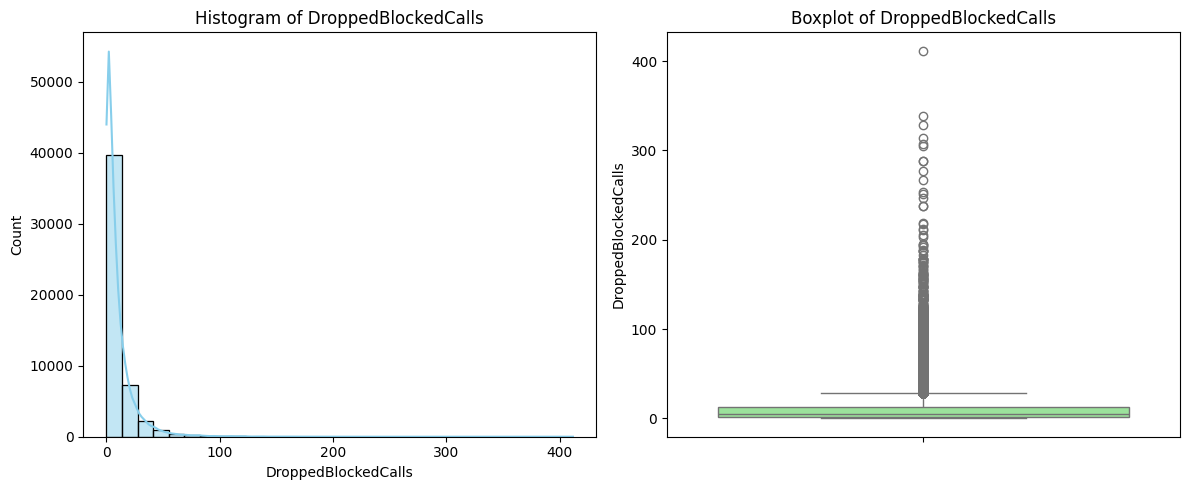

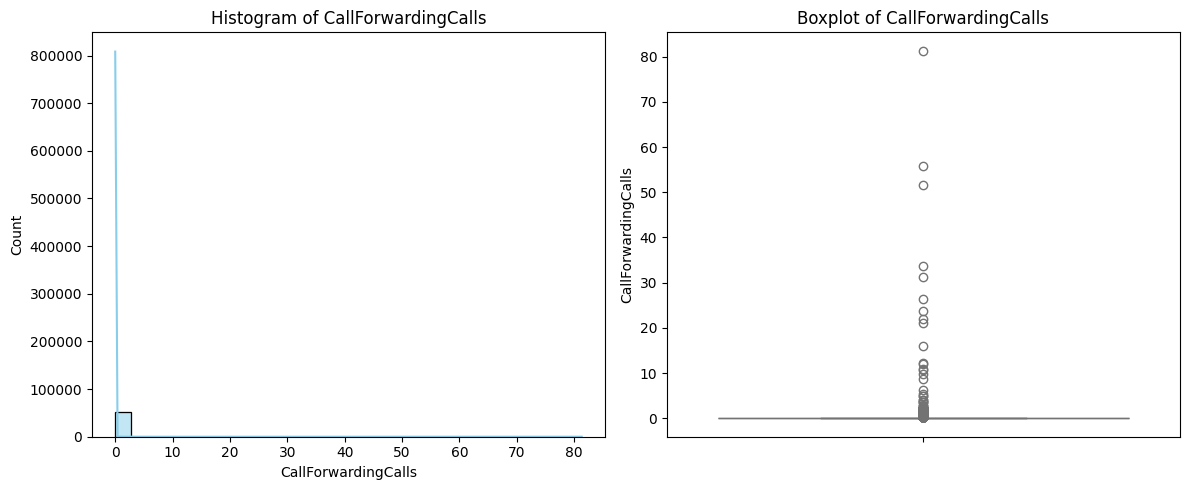

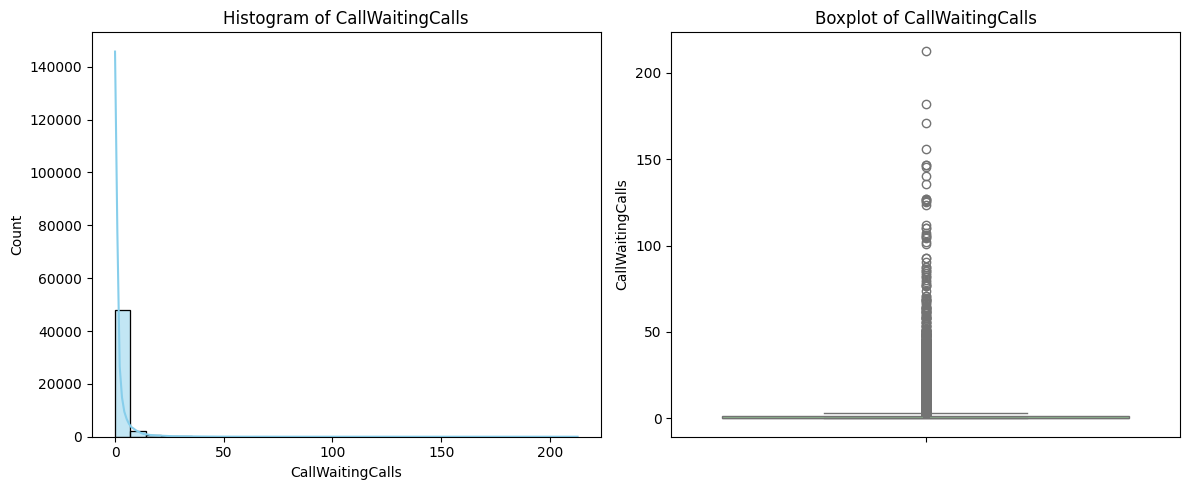

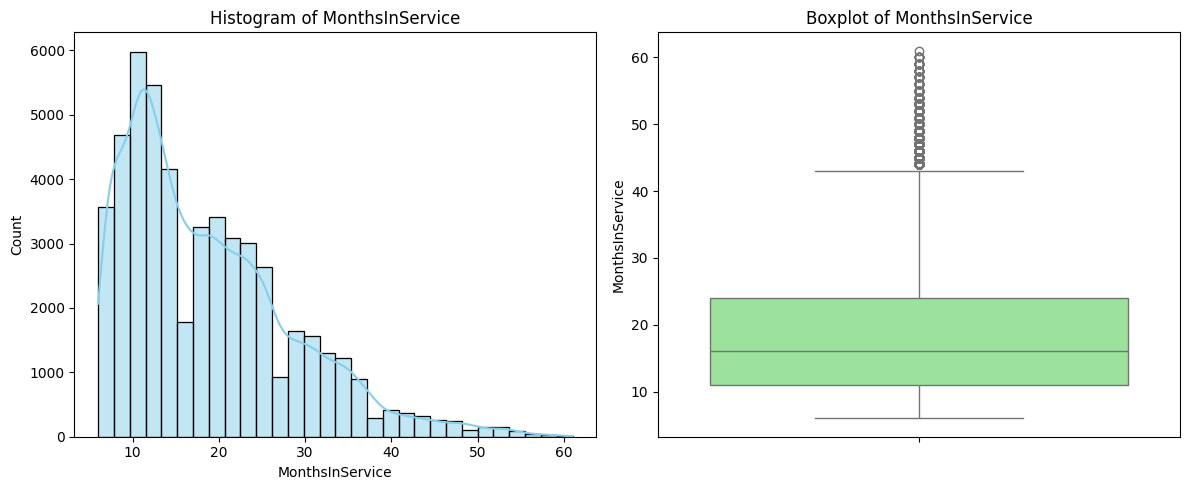

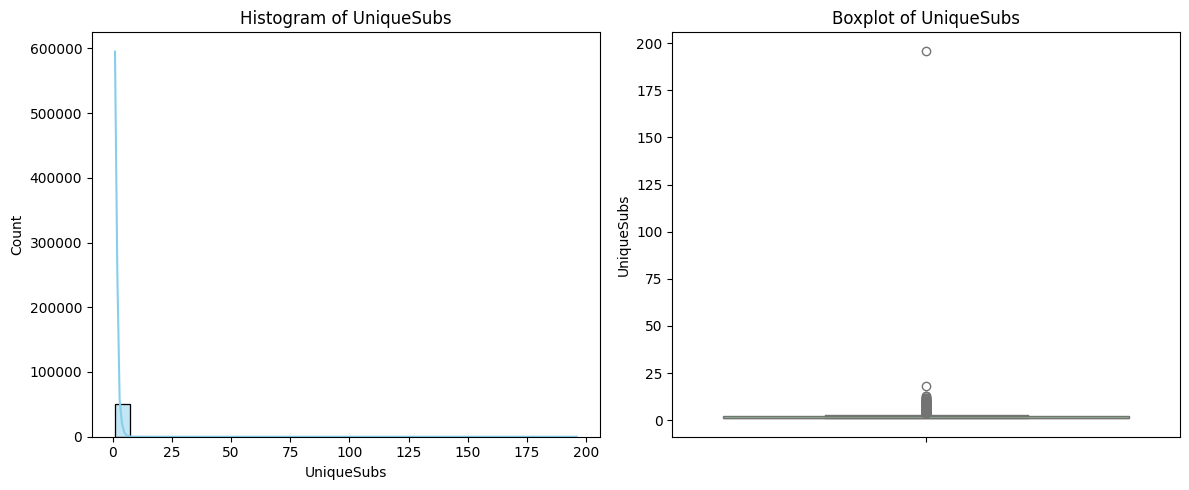

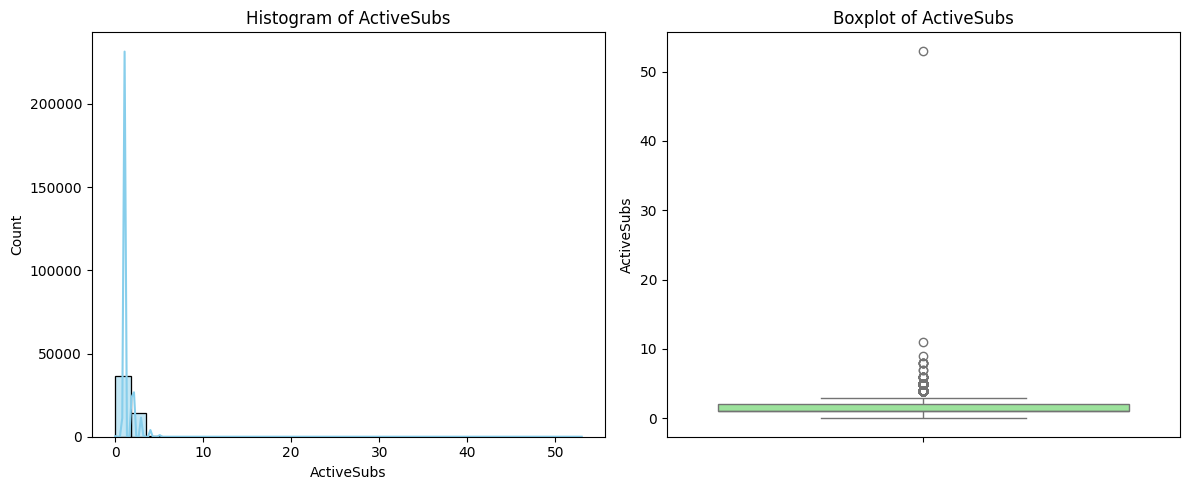

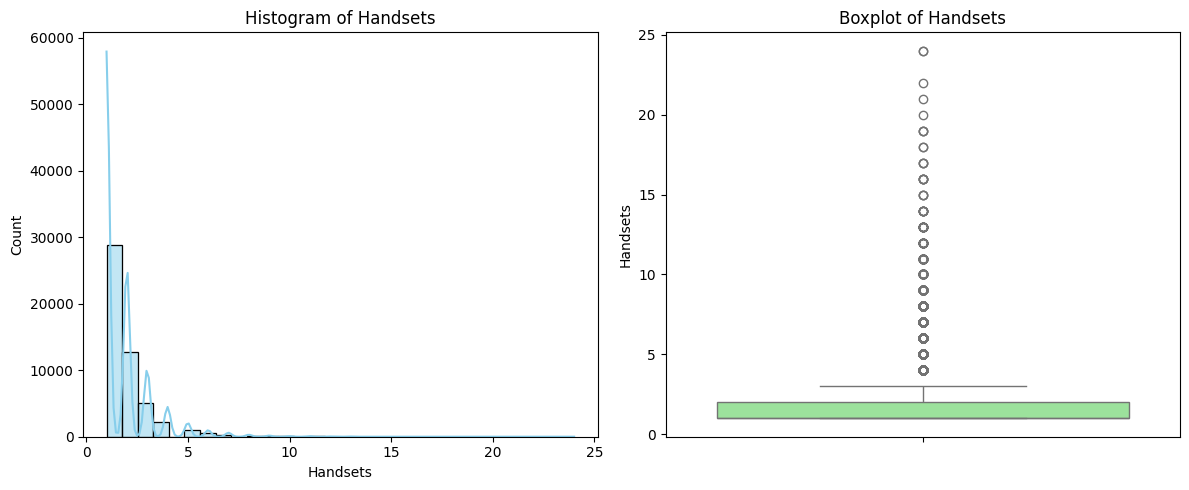

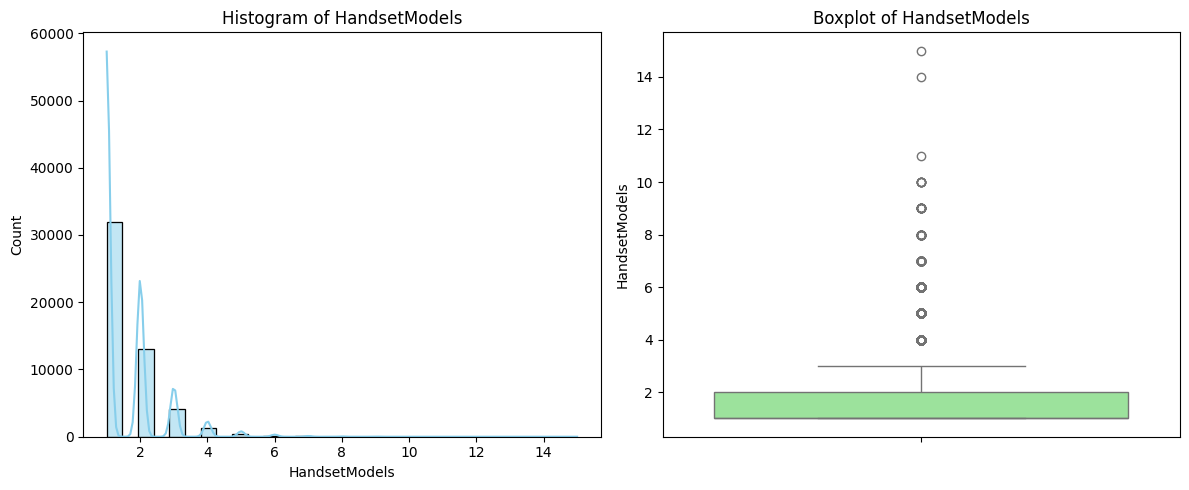

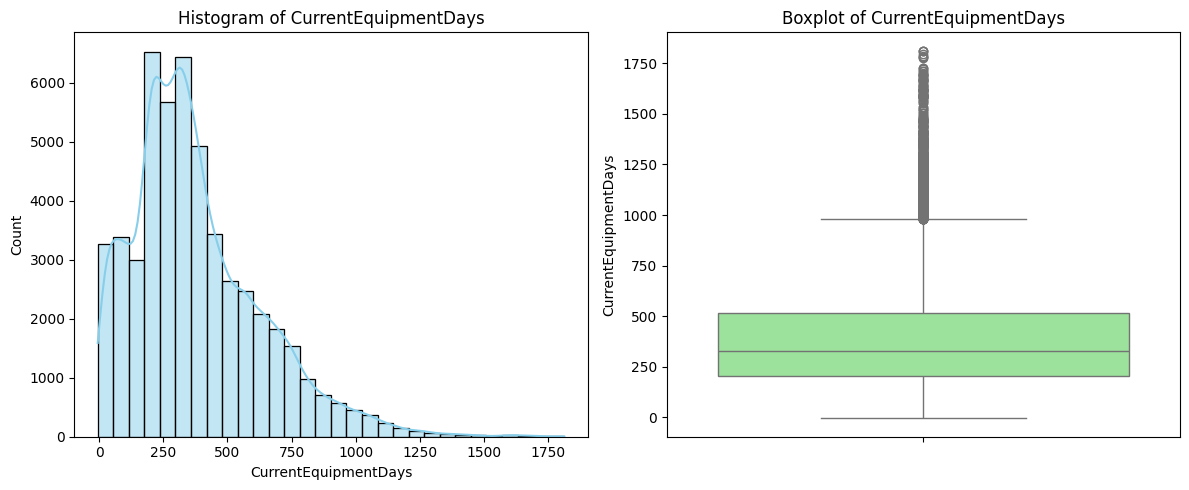

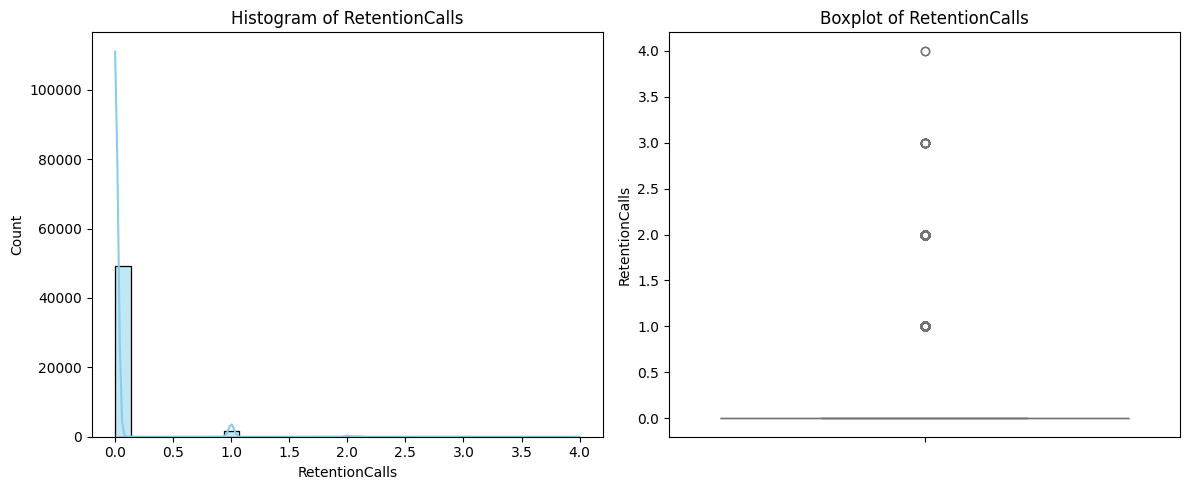

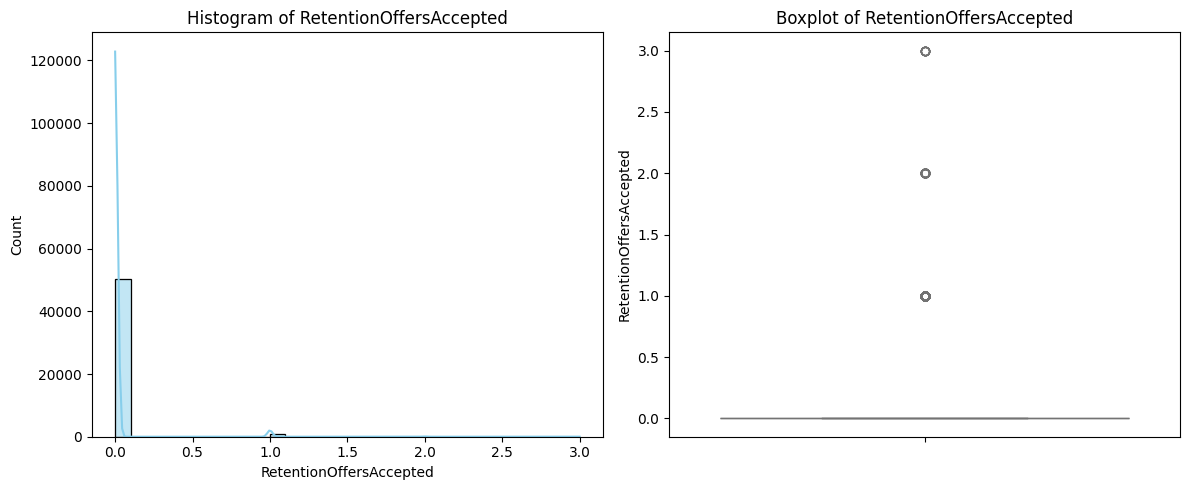

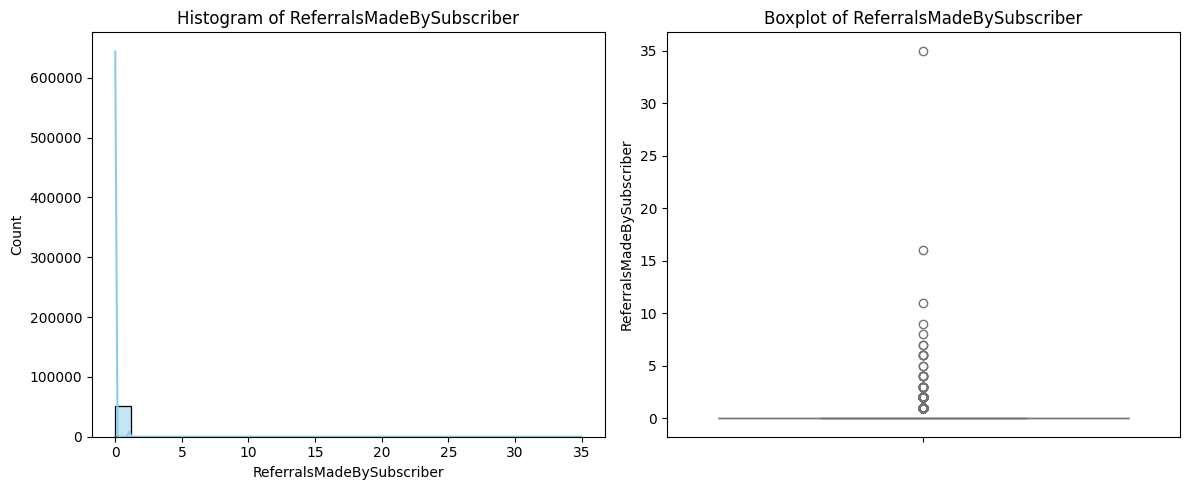

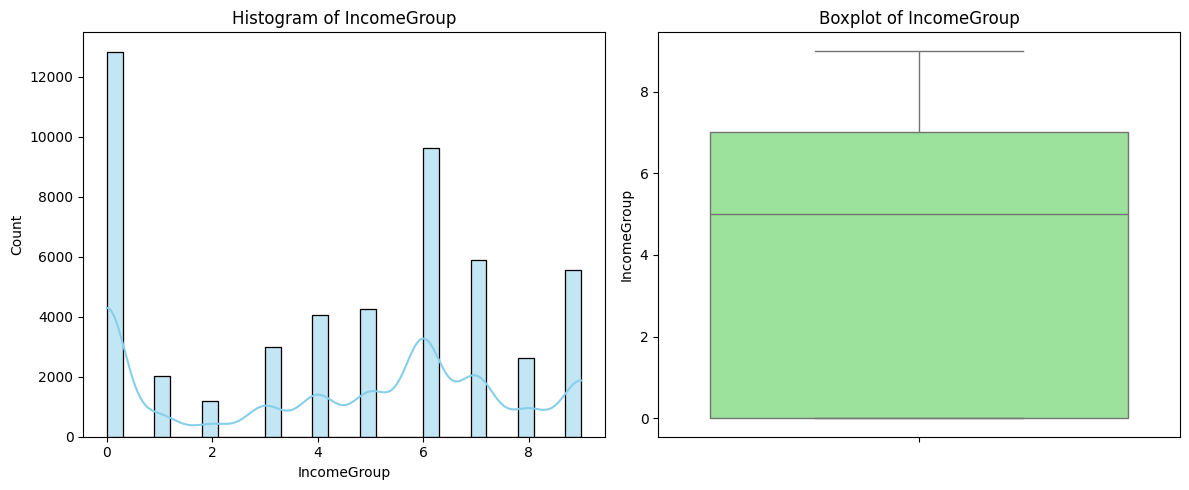

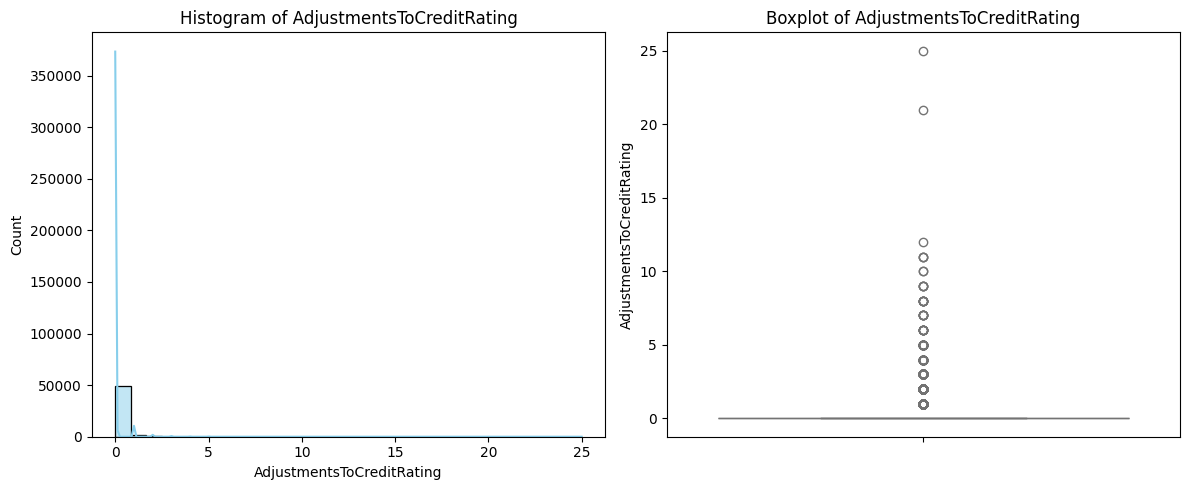

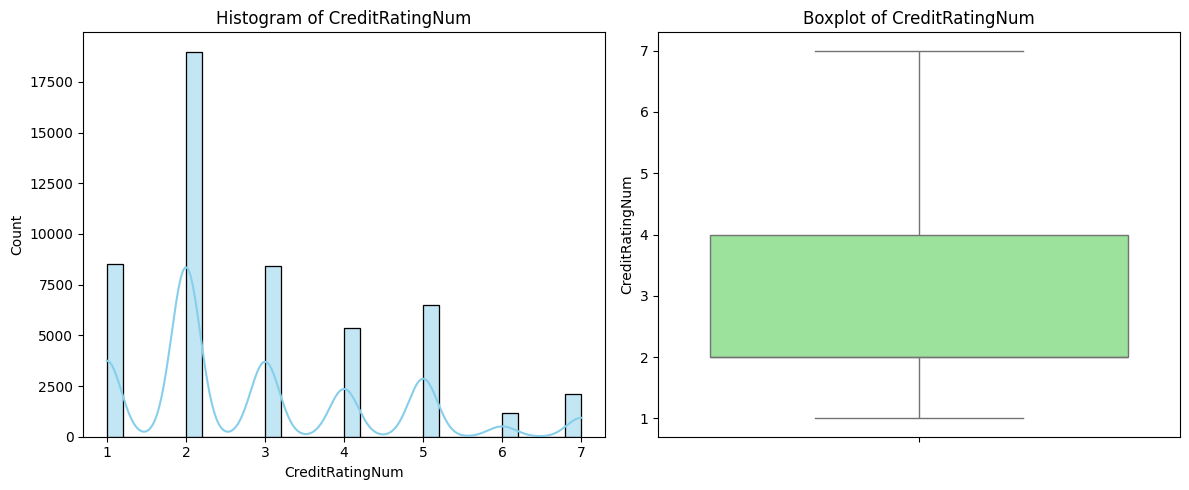

In [18]:
# Set figure size and layout
for col in numeric_cols.columns:
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(data_joined[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Histogram of {col}')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=data_joined[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

In [19]:
corr_matrix = numeric_cols.corr()
corr_matrix

,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,Handsets,HandsetModels,CurrentEquipmentDays,RetentionCalls,RetentionOffersAccepted,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating,CreditRatingNum
MonthlyRevenue,1.000000,0.712968,0.629835,0.407372,0.787865,0.303638,-0.027429,-0.016571,0.429911,0.232162,0.449610,0.189039,0.200670,0.604635,0.494493,0.373571,0.640922,0.471562,0.416785,0.011413,0.468730,-0.002305,-0.014309,-0.041631,0.242457,0.235636,-0.217373,0.011142,0.015402,0.018933,-0.081593,0.034164,0.138478
MonthlyMinutes,0.712968,1.000000,0.584014,0.392377,0.571582,0.112722,-0.045172,-0.040720,0.593126,0.318009,0.645437,0.375658,0.288409,0.828031,0.693354,0.557527,0.770326,0.763910,0.572790,0.018664,0.614813,-0.068506,-0.029803,-0.065828,0.301769,0.291961,-0.310101,0.009560,0.014874,0.067452,-0.144348,0.045164,0.202249
TotalRecurringCharge,0.629835,0.584014,1.000000,0.311077,0.202951,0.073767,-0.016201,-0.025531,0.352390,0.178886,0.357709,0.152470,0.148592,0.480432,0.408444,0.306259,0.550819,0.367319,0.333693,0.014085,0.354574,-0.047954,-0.020661,-0.056717,0.233702,0.225111,-0.247995,-0.022028,-0.002306,0.036715,-0.077023,0.043396,0.131774
DirectorAssistedCalls,0.407372,0.392377,0.311077,1.000000,0.287366,0.070091,-0.026105,-0.016049,0.263450,0.139936,0.304613,0.093301,0.132401,0.280689,0.315140,0.186031,0.418529,0.273295,0.252728,0.002323,0.305112,0.017861,-0.002697,-0.014810,0.184442,0.172056,-0.121587,0.008477,0.013311,-0.001083,-0.017408,0.022424,0.075046
OverageMinutes,0.787865,0.571582,0.202951,0.287366,1.000000,0.064085,-0.028438,-0.018646,0.331685,0.190500,0.362670,0.137771,0.163859,0.515630,0.405672,0.319870,0.517877,0.390641,0.329256,0.003702,0.456640,0.001236,-0.002879,-0.012533,0.142617,0.143260,-0.124260,0.014811,0.009279,0.010081,-0.049999,0.020464,0.080810
RoamingCalls,0.303638,0.112722,0.073767,0.070091,0.064085,1.000000,-0.053853,-0.090723,0.068502,0.029203,0.039327,0.020460,0.024516,0.045897,0.045332,0.019837,0.062661,0.031633,0.060832,0.003243,0.035981,-0.010866,-0.003860,-0.003190,0.024343,0.022872,-0.029030,-0.002067,-0.000816,-0.006843,-0.015228,0.004398,0.016033
PercChangeMinutes,-0.027429,-0.045172,-0.016201,-0.026105,-0.028438,-0.053853,1.000000,0.609520,-0.081140,-0.055395,-0.086167,-0.039986,-0.028917,-0.106371,-0.063584,-0.070713,-0.109599,-0.089065,-0.087181,-0.004802,-0.129611,0.004182,0.001818,0.008530,-0.012484,-0.012226,-0.006066,-0.021080,-0.008200,-0.001986,0.011411,-0.004287,-0.032420
PercChangeRevenues,-0.016571,-0.040720,-0.025531,-0.016049,-0.018646,-0.090723,0.609520,1.000000,-0.037301,-0.033044,-0.055782,-0.032517,0.013148,-0.079493,-0.041648,-0.047406,-0.080709,-0.052559,-0.045741,-0.002365,-0.093950,-0.006877,0.002537,0.005136,-0.018092,-0.017872,0.005838,-0.019045,-0.012160,-0.001788,0.005717,-0.005517,-0.021146
DroppedCalls,0.429911,0.593126,0.352390,0.263450,0.331685,0.068502,-0.081140,-0.037301,1.000000,0.185124,0.543263,0.294747,0.264223,0.517854,0.564465,0.394289,0.574093,0.601072,0.715420,0.004301,0.396783,-0.046175,-0.021223,-0.049663,0.225186,0.217869,-0.216536,0.020308,0.014858,0.029546,-0.096316,0.031039,0.190854
BlockedCalls,0.232162,0.318009,0.178886,0.139936,0.190500,0.029203,-0.055395,-0.033044,0.185124,1.000000,0.255713,0.199638,0.262207,0.260401,0.230012,0.188910,0.301752,0.330684,0.816328,0.015123,0.286784,-0.072684,-0.016170,-0.026820,0.088458,0.085308,-0.124673,0.010841,0.008350,0.023848,-0.065375,0.004167,0.095268


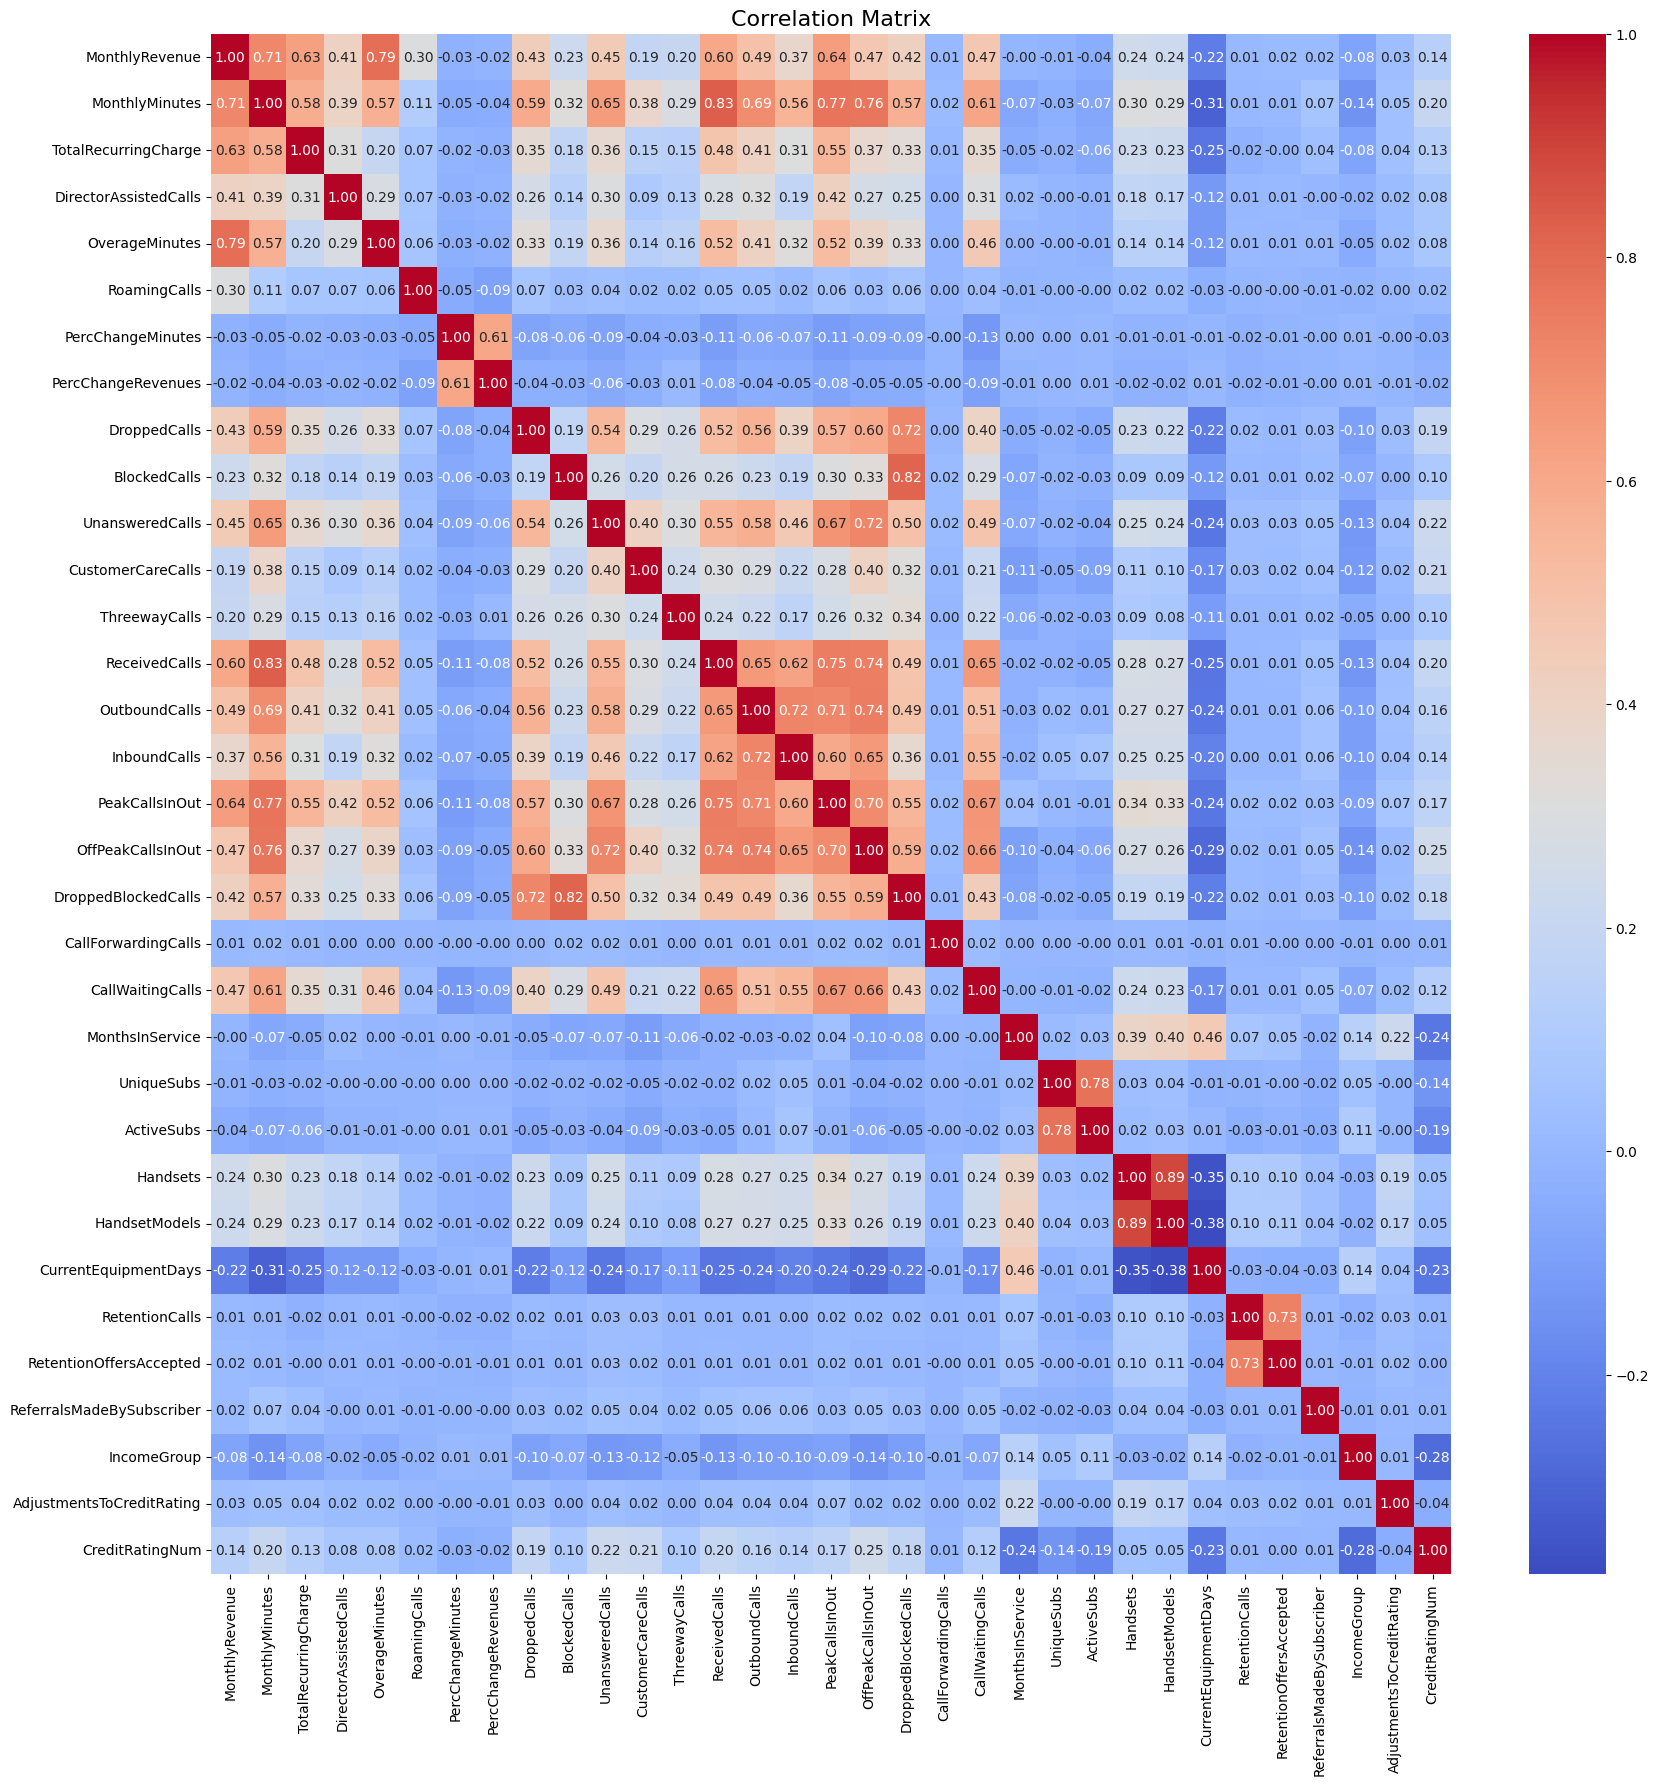

In [20]:
plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix", fontsize=16)
plt.savefig(get_path("images/Correlation_Matrix.png"))
plt.show()

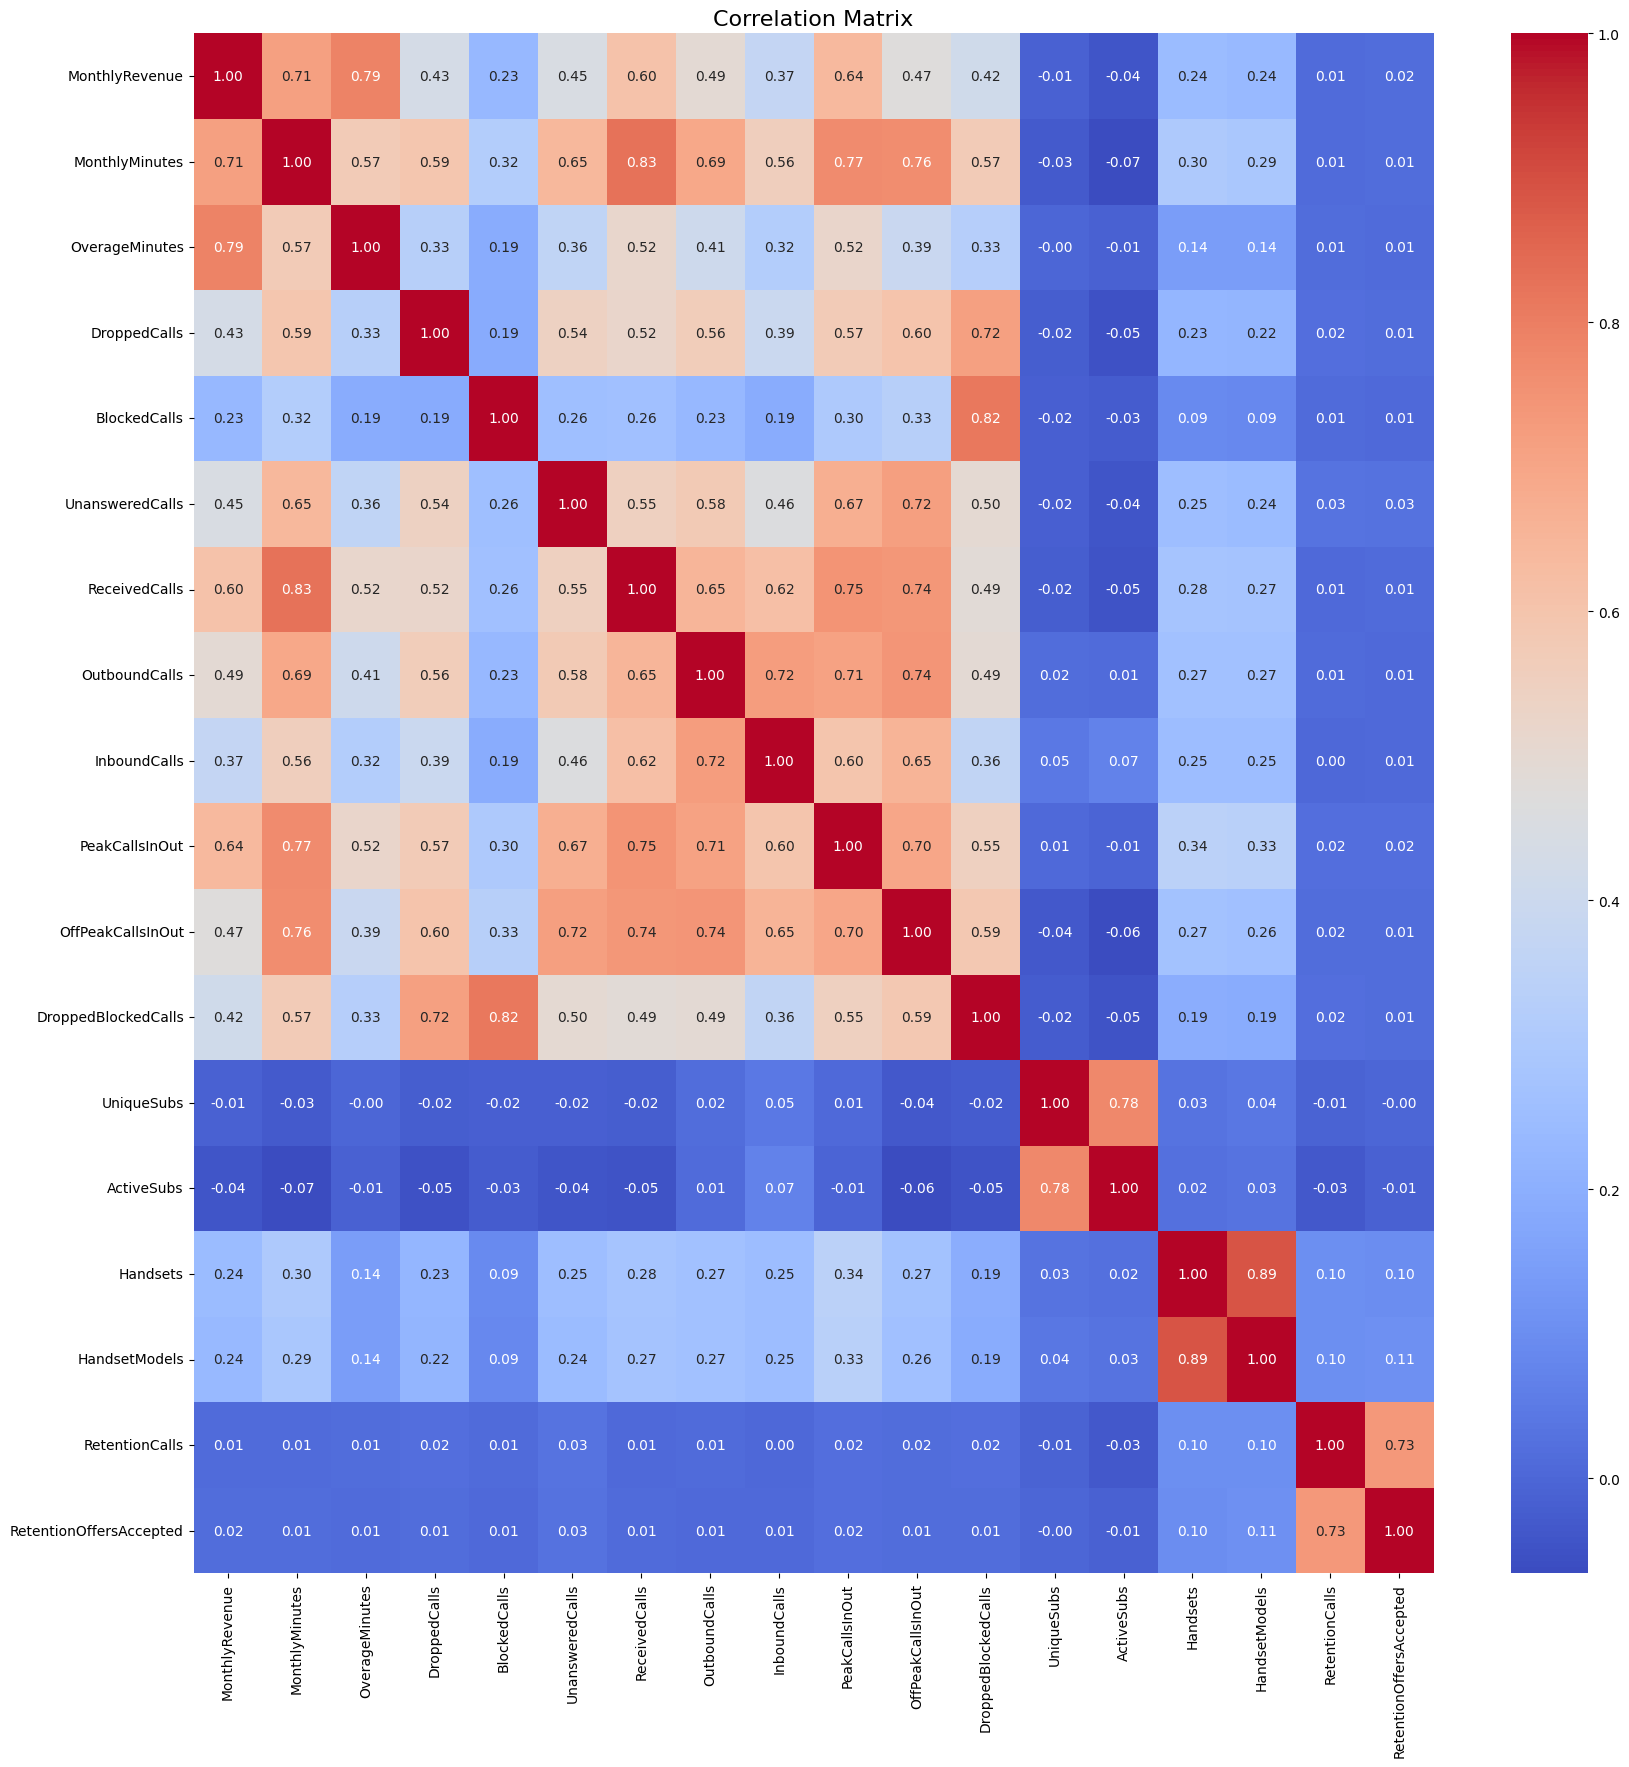

In [21]:
mask = (abs(corr_matrix) >= 0.7)
np.fill_diagonal(mask.values, False)
rows_with_high_corr = mask.any(axis=1)
cols_with_high_corr = mask.any(axis=0)
high_corr = corr_matrix.loc[rows_with_high_corr, cols_with_high_corr]

plt.figure(figsize=(20, 20))
sns.heatmap(high_corr, annot=True, cmap="coolwarm", fmt=".2f", mask=high_corr.isnull())
plt.title("Correlation Matrix", fontsize=16)

plt.savefig(get_path("images/High_Correlation_Matrix.png"))

plt.show()

In [22]:
cols_to_check = ["MonthlyRevenue", "TotalRecurringCharge", "CurrentEquipmentDays"]
data_joined.drop(data_joined[(data_joined[cols_to_check] < 0).any(axis=1)].index, inplace=True)
data_joined.reset_index(drop=True, inplace=True)
data_joined

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,PrizmCode,Occupation,MaritalStatus,CreditRatingNum,CreditRatingLabel
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,SEAPOR503,2.0,2.0,361.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,1,0,No,No,0,4,No,0,30,Yes,Suburban,Professional,No,1,Highest
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,PITHOM412,2.0,1.0,1504.0,Yes,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,Yes,No,0,5,No,0,30,No,Suburban,Professional,Yes,4,Medium
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,MILMIL414,1.0,1.0,1812.0,Yes,No,No,No,No,Unknown,No,No,No,No,No,Yes,0,0,Yes,No,0,6,No,0,Unknown,No,Town,Crafts,Yes,3,Good
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,PITHOM412,9.0,4.0,458.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,Yes,No,0,6,No,0,10,No,Other,Other,No,4,Medium
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,OKCTUL918,4.0,3.0,852.0,No,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,Yes,0,9,No,1,10,No,Other,Professional,Yes,1,Highest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50957,3399958,Yes,48.46,366.0,45.0,0.25,3.0,0.0,0.0,0.0,9.3,2.7,48.3,0.0,0.0,58.9,17.0,1.3,160.3,33.3,12.0,0.0,0.3,29,1,1,LAXSFN818,2.0,2.0,526.0,No,Yes,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,No,No,0,6,No,0,60,No,Suburban,Other,Yes,1,Highest
50958,3399974,No,95.17,1745.0,85.0,0.99,45.0,4.7,122.0,15.9,16.7,0.7,41.3,0.0,0.0,681.5,89.7,33.3,318.7,248.3,17.3,0.0,14.3,29,1,1,LAXCDG310,2.0,2.0,464.0,Yes,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,No,0,9,No,1,60,No,Other,Other,No,3,Good
50959,3399978,Yes,48.46,366.0,45.0,0.25,3.0,0.0,0.0,0.0,71.7,4.3,287.0,1.3,13.7,1225.3,430.3,87.7,1359.0,910.3,76.0,0.0,6.7,25,1,1,LAXCDG310,3.0,2.0,378.0,No,No,Yes,No,No,Known,No,No,No,No,No,Yes,0,0,No,No,0,7,No,1,80,No,Other,Clerical,No,5,Low
50960,3399990,No,48.46,366.0,45.0,0.25,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31,1,1,NEVPOW619,2.0,2.0,433.0,Yes,No,Yes,No,No,Unknown,No,No,No,No,No,No,0,0,No,No,0,9,No,0,30,No,Other,Other,No,5,Low


In [23]:
neg_rows = data_joined[(data_joined[cols_to_check] < 0).any(axis=1)]
display(neg_rows)

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,PrizmCode,Occupation,MaritalStatus,CreditRatingNum,CreditRatingLabel


In [24]:
data_joined["MaritalStatus"].unique()

array(['No', 'Yes', 'Unknown'], dtype=object)

# FEATURE ENGINEERING

In [25]:
data_fe = data_joined.copy()
data_fe.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,PrizmCode,Occupation,MaritalStatus,CreditRatingNum,CreditRatingLabel
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,SEAPOR503,2.0,2.0,361.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,1,0,No,No,0,4,No,0,30,Yes,Suburban,Professional,No,1,Highest
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,PITHOM412,2.0,1.0,1504.0,Yes,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,Yes,No,0,5,No,0,30,No,Suburban,Professional,Yes,4,Medium
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,MILMIL414,1.0,1.0,1812.0,Yes,No,No,No,No,Unknown,No,No,No,No,No,Yes,0,0,Yes,No,0,6,No,0,Unknown,No,Town,Crafts,Yes,3,Good
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,PITHOM412,9.0,4.0,458.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,Yes,No,0,6,No,0,10,No,Other,Other,No,4,Medium
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,OKCTUL918,4.0,3.0,852.0,No,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,Yes,0,9,No,1,10,No,Other,Professional,Yes,1,Highest


* Encoding Binary variables

In [26]:
non_binary_cols = ['CreditRatingLabel', 'PrizmCode', 'Occupation', 'MaritalStatus', 'ServiceArea', 'Homeownership', 'HandsetPrice']
non_binary_cols


['CreditRatingLabel',
 'PrizmCode',
 'Occupation',
 'MaritalStatus',
 'ServiceArea',
 'Homeownership',
 'HandsetPrice']

In [27]:
binary_col_names = list(data_fe.select_dtypes(include=['object']).columns)
binary_col_names

['Churn',
 'ServiceArea',
 'ChildrenInHH',
 'HandsetRefurbished',
 'HandsetWebCapable',
 'TruckOwner',
 'RVOwner',
 'Homeownership',
 'BuysViaMailOrder',
 'RespondsToMailOffers',
 'OptOutMailings',
 'NonUSTravel',
 'OwnsComputer',
 'HasCreditCard',
 'NewCellphoneUser',
 'NotNewCellphoneUser',
 'OwnsMotorcycle',
 'HandsetPrice',
 'MadeCallToRetentionTeam',
 'PrizmCode',
 'Occupation',
 'MaritalStatus',
 'CreditRatingLabel']

In [28]:
data_fe['CreditRatingLabel'].unique()

array(['Highest', 'Medium', 'Good', 'VeryLow', 'High', 'Low', 'Lowest'],
      dtype=object)

In [29]:
mapping = ({'Yes' : 1, 'No' : 0})
binary_cols = [col for col in binary_col_names if col not in non_binary_cols]
data_fe[binary_cols] = data_fe[binary_cols].apply(lambda col: col.map(mapping))
data_fe["Homeownership"] = data_fe["Homeownership"].map({'Known': 1, 'Unknown': 0})
data_fe["CreditRatingLabel"] = data_fe["CreditRatingLabel"].map({'Lowest': 0,
                                                                 'VeryLow': 1,
                                                                 'Low': 2,
                                                                 'Medium': 3,
                                                                 'Good': 4,
                                                                 'High': 5,
                                                                 'Highest': 6})

In [30]:
data_fe.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,PrizmCode,Occupation,MaritalStatus,CreditRatingNum,CreditRatingLabel
0,3000002,1,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,SEAPOR503,2.0,2.0,361.0,0,0,1,0,0,1,1,1,0,0,1,1,1,0,0,0,0,4,0,0,30,1,Suburban,Professional,No,1,6
1,3000010,1,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,PITHOM412,2.0,1.0,1504.0,1,0,0,0,0,1,1,1,0,0,1,1,0,0,1,0,0,5,0,0,30,0,Suburban,Professional,Yes,4,3
2,3000014,0,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,MILMIL414,1.0,1.0,1812.0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,6,0,0,Unknown,0,Town,Crafts,Yes,3,4
3,3000022,0,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,PITHOM412,9.0,4.0,458.0,0,0,1,0,0,1,1,1,0,0,0,1,0,0,1,0,0,6,0,0,10,0,Other,Other,No,4,3
4,3000026,1,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,OKCTUL918,4.0,3.0,852.0,0,0,0,0,0,1,1,1,0,0,1,1,0,0,0,1,0,9,0,1,10,0,Other,Professional,Yes,1,6


* Adress 'Unknown' in HadsetPrice variable : Arounf 57% of the value is 'Unknown' hence we decided to drop this variable

In [31]:
# Count 'Unknown' values in HandsetPrice
unknown_count = data_fe['HandsetPrice'].value_counts().get('Unknown')
unknown_count

# Percentage of 'Unknown' values in HandsetPrice
unknown_percentage = (unknown_count / len(data_fe)) * 100
print(unknown_percentage)

# Drop HandsetPrice variable
data_fe = data_fe.drop(columns=['HandsetPrice'])

56.86197558965503


In [32]:
data_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50962 entries, 0 to 50961
Data columns (total 56 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 50962 non-null  int64  
 1   Churn                      50962 non-null  int64  
 2   MonthlyRevenue             50962 non-null  float64
 3   MonthlyMinutes             50962 non-null  float64
 4   TotalRecurringCharge       50962 non-null  float64
 5   DirectorAssistedCalls      50962 non-null  float64
 6   OverageMinutes             50962 non-null  float64
 7   RoamingCalls               50962 non-null  float64
 8   PercChangeMinutes          50962 non-null  float64
 9   PercChangeRevenues         50962 non-null  float64
 10  DroppedCalls               50962 non-null  float64
 11  BlockedCalls               50962 non-null  float64
 12  UnansweredCalls            50962 non-null  float64
 13  CustomerCareCalls          50962 non-null  flo

### One Hot Coding
* One hot coding is applied to 'ServiceArea', 'PrizmCode', 'Occupation', 'MaritalStatus'

In [33]:
def ohe_cat(ColName, df):
    encoder = OneHotEncoder(sparse_output = False)
    encoded_cat = encoder.fit_transform(np.array(df[ColName]).reshape(-1,1))
    encoded_cat = pd.DataFrame(encoded_cat, columns = [f'{ColName}_{cat}' for cat in sorted(df[ColName].unique())])
    df = df.drop(ColName, axis = 'columns')
    df = pd.concat([df, encoded_cat], axis = 1)
    return df

##### Service Area

In [34]:
le = LabelEncoder()
data_fe["ServiceArea"] = le.fit_transform(data_fe.ServiceArea.str[:3])
data_fe.filter(like='ServiceArea')

,ServiceArea
0,48
1,45
2,27
3,45
4,41
...,...
50957,24
50958,24
50959,24
50960,30


##### Prizm Code

In [35]:
data_fe = ohe_cat('PrizmCode', data_fe)
data_fe.filter(like='PrizmCode')

,PrizmCode_Other,PrizmCode_Rural,PrizmCode_Suburban,PrizmCode_Town
0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0
...,...,...,...,...
50957,0.0,0.0,1.0,0.0
50958,1.0,0.0,0.0,0.0
50959,1.0,0.0,0.0,0.0
50960,1.0,0.0,0.0,0.0


##### Occupation

In [36]:
le = LabelEncoder()
data_fe["Occupation"] = le.fit_transform(data_fe["Occupation"])
data_fe.filter(like="Occupation")

,Occupation
0,4
1,4
2,1
3,3
4,4
...,...
50957,3
50958,3
50959,0
50960,3


In [37]:
data_fe["MaritalStatus"].unique()

array(['No', 'Yes', 'Unknown'], dtype=object)

##### Marital Status

In [38]:
data_fe = ohe_cat('MaritalStatus', data_fe)
data_fe.filter(like='MaritalStatus')

,MaritalStatus_No,MaritalStatus_Unknown,MaritalStatus_Yes
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0
...,...,...,...
50957,0.0,0.0,1.0
50958,1.0,0.0,0.0
50959,1.0,0.0,0.0
50960,1.0,0.0,0.0


In [39]:
# check for missing values
def check_missing(df):
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending = False)
    if len(missing) > 0:
        print("Missing values found in the following columns:")
        print(missing)
    else:
        print("No missing values found.")
check_missing(data_fe)

No missing values found.


In [40]:
data_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50962 entries, 0 to 50961
Data columns (total 61 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 50962 non-null  int64  
 1   Churn                      50962 non-null  int64  
 2   MonthlyRevenue             50962 non-null  float64
 3   MonthlyMinutes             50962 non-null  float64
 4   TotalRecurringCharge       50962 non-null  float64
 5   DirectorAssistedCalls      50962 non-null  float64
 6   OverageMinutes             50962 non-null  float64
 7   RoamingCalls               50962 non-null  float64
 8   PercChangeMinutes          50962 non-null  float64
 9   PercChangeRevenues         50962 non-null  float64
 10  DroppedCalls               50962 non-null  float64
 11  BlockedCalls               50962 non-null  float64
 12  UnansweredCalls            50962 non-null  float64
 13  CustomerCareCalls          50962 non-null  flo

# Feaure Creation

In [41]:
data_fe["In_Out_Ratio"] = data_fe["InboundCalls"] / data_fe["OutboundCalls"].replace(0, np.nan)
data_fe["In_Out_Ratio"] = data_fe["In_Out_Ratio"].fillna(0)
data_fe.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,MadeCallToRetentionTeam,Occupation,CreditRatingNum,CreditRatingLabel,PrizmCode_Other,PrizmCode_Rural,PrizmCode_Suburban,PrizmCode_Town,MaritalStatus_No,MaritalStatus_Unknown,MaritalStatus_Yes,In_Out_Ratio
0,3000002,1,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,48,2.0,2.0,361.0,0,0,1,0,0,1,1,1,0,0,1,1,1,0,0,0,0,4,0,0,1,4,1,6,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.000000
1,3000010,1,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,45,2.0,1.0,1504.0,1,0,0,0,0,1,1,1,0,0,1,1,0,0,1,0,0,5,0,0,0,4,4,3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.000000
2,3000014,0,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,27,1.0,1.0,1812.0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,6,0,0,0,1,3,4,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.000000
3,3000022,0,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,45,9.0,4.0,458.0,0,0,1,0,0,1,1,1,0,0,0,1,0,0,1,0,0,6,0,0,0,3,4,3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.396975
4,3000026,1,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,41,4.0,3.0,852.0,0,0,0,0,0,1,1,1,0,0,1,1,0,0,0,1,0,9,0,1,0,4,1,6,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000


##### Selecting feature

In [42]:
X = data_fe.drop('Churn', axis='columns')
y = data_fe['Churn']
important = mutual_info_classif(X,y, random_state = 22)
important_feat = pd.Series(important, X.columns)
important_feat = important_feat.sort_values(ascending = False)

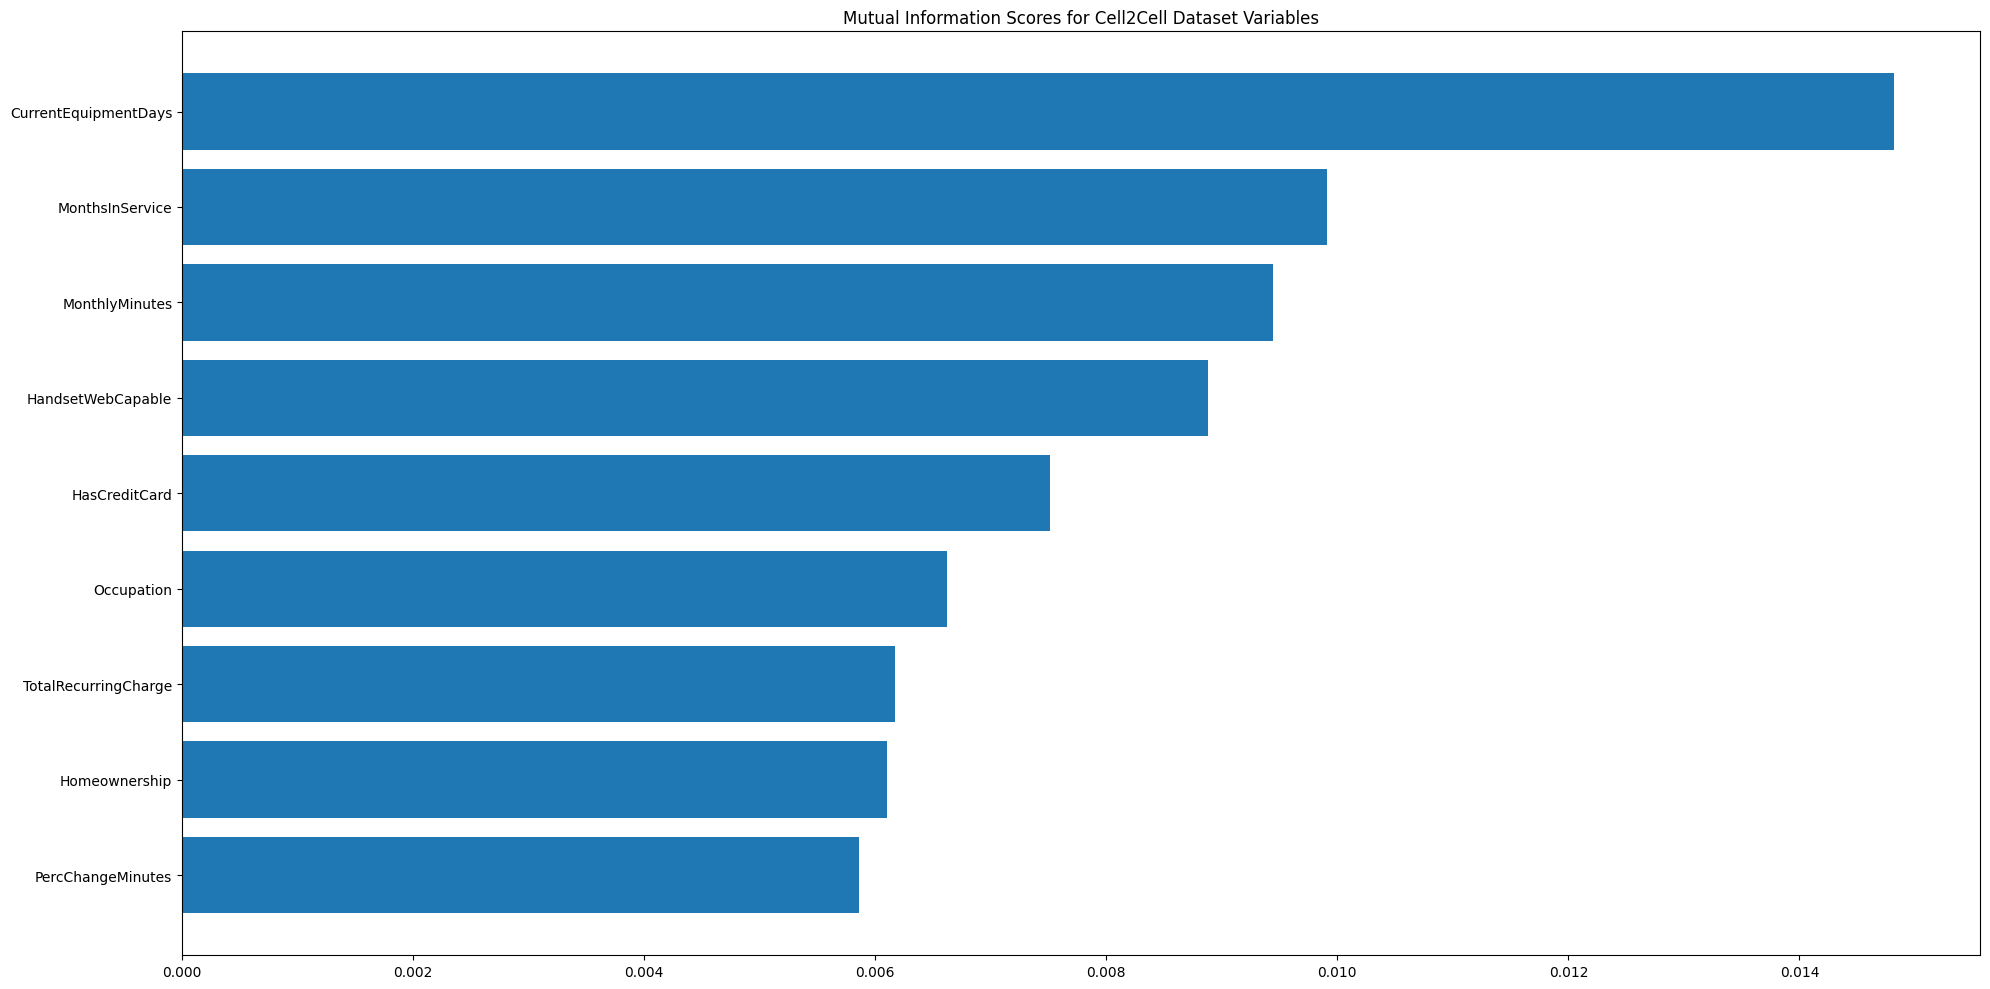

In [43]:
def plot_feat_importances(scores):
    scores = scores.sort_values(ascending=True)  # for horizontal bar plot
    width = np.arange(len(scores))
    ticks = list(scores.index)

    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores for Cell2Cell Dataset Variables")
    plt.tight_layout()
    plt.savefig(get_path("images/Mutual_Information_Scores.jpeg"))
    plt.show()

# 4. Plot only features with value > 0.005
plt.figure(dpi=100, figsize=(20, 10))
plot_feat_importances(important_feat[important_feat > 0.005])

##### Remove feature with high correlation

In [44]:
# Crop customer_id
dropped_cols = ["CustomerID"]
data_fe = data_fe.drop(columns=dropped_cols)

In [45]:
corr= data_fe.corr()

corr = corr[abs(corr) >= 0.7].dropna(how = 'all', axis = 0).dropna(how = 'all', axis = 1)
dropped_cols = []
# Getting the Upper Triangle of the co-relation matrix
matrix = np.triu(corr)
row_idx, col_idx = np.where(np.abs(matrix) >= 0.7)
# Print the highly correlated variable pairs
for i in range(len(row_idx)):
    row = corr.index[row_idx[i]]
    col = corr.columns[col_idx[i]]
    if row != col:
        # Compare two values and return the index of the minimum value
        min_idx = important_feat[[row,col]].idxmin()
        dropped_cols.append(min_idx)
dropped_cols

['MonthlyRevenue',
 'OverageMinutes',
 'ReceivedCalls',
 'PeakCallsInOut',
 'OffPeakCallsInOut',
 'DroppedCalls',
 'DroppedBlockedCalls',
 'UnansweredCalls',
 'ReceivedCalls',
 'ReceivedCalls',
 'InboundCalls',
 'PeakCallsInOut',
 'OutboundCalls',
 'ActiveSubs',
 'Handsets',
 'Homeownership',
 'IncomeGroup',
 'RespondsToMailOffers',
 'IncomeGroup',
 'RetentionCalls',
 'RetentionCalls',
 'CreditRatingLabel']

In [46]:
data_sf = data_fe.drop(columns=dropped_cols)

In [47]:
data_sf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50962 entries, 0 to 50961
Data columns (total 44 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      50962 non-null  int64  
 1   MonthlyMinutes             50962 non-null  float64
 2   TotalRecurringCharge       50962 non-null  float64
 3   DirectorAssistedCalls      50962 non-null  float64
 4   RoamingCalls               50962 non-null  float64
 5   PercChangeMinutes          50962 non-null  float64
 6   PercChangeRevenues         50962 non-null  float64
 7   BlockedCalls               50962 non-null  float64
 8   CustomerCareCalls          50962 non-null  float64
 9   ThreewayCalls              50962 non-null  float64
 10  CallForwardingCalls        50962 non-null  float64
 11  CallWaitingCalls           50962 non-null  float64
 12  MonthsInService            50962 non-null  int64  
 13  UniqueSubs                 50962 non-null  int

#### Normalisation
* Normalize numerical values

In [48]:
data_norm = data_sf.copy()
data_norm.head()

,Churn,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,RoamingCalls,PercChangeMinutes,PercChangeRevenues,BlockedCalls,CustomerCareCalls,ThreewayCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ServiceArea,HandsetModels,CurrentEquipmentDays,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,BuysViaMailOrder,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,OwnsMotorcycle,AdjustmentsToCreditRating,MadeCallToRetentionTeam,Occupation,CreditRatingNum,PrizmCode_Other,PrizmCode_Rural,PrizmCode_Suburban,PrizmCode_Town,MaritalStatus_No,MaritalStatus_Unknown,MaritalStatus_Yes,In_Out_Ratio
0,1,219.0,22.0,0.25,0.0,-157.0,-19.0,0.7,0.0,0.0,0.0,0.3,61,2,48,2.0,361.0,0,0,1,0,0,1,0,0,1,1,0,0,0,0,0,0,1,4,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.000000
1,1,10.0,17.0,0.00,0.0,-4.0,0.0,0.0,0.0,0.0,0.0,0.0,58,1,45,1.0,1504.0,1,0,0,0,0,1,0,0,1,1,0,1,0,0,0,0,0,4,4,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.000000
2,0,8.0,38.0,0.00,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,60,1,27,1.0,1812.0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,3,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.000000
3,0,1312.0,75.0,1.24,0.0,157.0,8.1,7.7,4.3,1.3,0.0,22.7,59,2,45,4.0,458.0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0,3,4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.396975
4,1,0.0,17.0,0.00,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,53,2,41,3.0,852.0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,4,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000


In [49]:
num_cols = [
  'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'RoamingCalls',
  'PercChangeMinutes', 'PercChangeRevenues', 'BlockedCalls', 'CustomerCareCalls',
  'ThreewayCalls', 'CallForwardingCalls', 'CallWaitingCalls',
  'MonthsInService', 'CurrentEquipmentDays',
]

scaler = StandardScaler()
data_norm[num_cols] = scaler.fit_transform(data_norm[num_cols])

float_cols = [col for col in data_norm.columns if col not in num_cols and data_norm[col].dtype == float]
data_norm[float_cols] = data_norm[float_cols].astype(int)
data_norm.head()

,Churn,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,RoamingCalls,PercChangeMinutes,PercChangeRevenues,BlockedCalls,CustomerCareCalls,ThreewayCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ServiceArea,HandsetModels,CurrentEquipmentDays,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,BuysViaMailOrder,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,OwnsMotorcycle,AdjustmentsToCreditRating,MadeCallToRetentionTeam,Occupation,CreditRatingNum,PrizmCode_Other,PrizmCode_Rural,PrizmCode_Suburban,PrizmCode_Town,MaritalStatus_No,MaritalStatus_Unknown,MaritalStatus_Yes,In_Out_Ratio
0,1,-0.578368,-1.042981,-0.288712,-0.125575,-0.567198,-0.451734,-0.309220,-0.366338,-0.258199,-0.02068,-0.275519,4.311451,2,48,2,-0.079386,0,0,1,0,0,1,0,0,1,1,0,0,0,0,0,0,1,4,1,0,0,1,0,1,0,0,0
1,1,-0.973970,-1.253088,-0.401122,-0.125575,0.029572,0.030435,-0.373146,-0.366338,-0.258199,-0.02068,-0.329296,4.005285,1,45,1,4.428333,1,0,0,0,0,1,0,0,1,1,0,1,0,0,0,0,0,4,4,0,0,1,0,0,0,1,0
2,0,-0.977755,-0.370639,-0.401122,-0.125575,0.037373,0.030435,-0.373146,-0.366338,-0.258199,-0.02068,-0.329296,4.209396,1,27,1,5.643012,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,3,0,0,0,1,0,0,1,0
3,0,1.490496,1.184152,0.156430,-0.125575,0.657546,0.235991,0.330044,0.477765,0.871570,-0.02068,3.739775,4.107340,2,45,4,0.303159,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0,3,4,1,0,0,0,1,0,0,0
4,1,-0.992898,-1.253088,-0.401122,-0.125575,0.045174,0.025359,-0.373146,-0.366338,-0.258199,-0.02068,-0.329296,3.495008,2,41,3,1.857001,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,4,1,1,0,0,0,0,0,1,0


In [50]:
data_norm.shape

(50962, 44)

In [59]:
len(num_cols)

13

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.59      0.66      7254
           1       0.35      0.56      0.43      2939

    accuracy                           0.58     10193
   macro avg       0.56      0.57      0.55     10193
weighted avg       0.65      0.58      0.60     10193



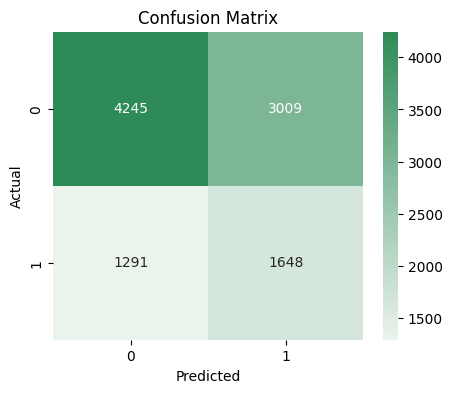

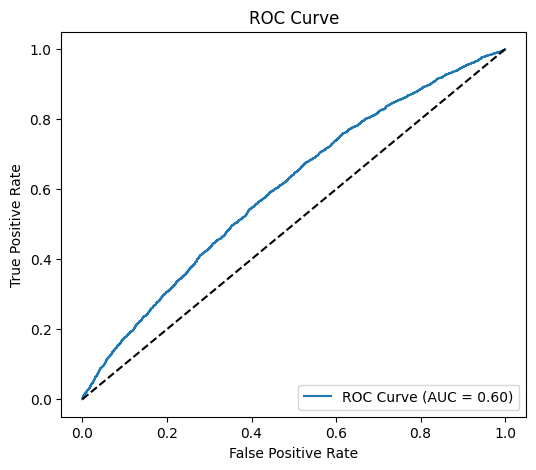

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [51]:
def logistic_regression_pipeline(df, target_col, model_name = "logistic_regression_model", test_size=0.2, seed=42):

  # Separate features and target
  X = df.drop(columns=[target_col])
  y = df[target_col]

  # Train/test split
  X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=seed, stratify=y
  )

  # Fit logistic regression
  model = LogisticRegression(
    max_iter=1000, random_state=seed, class_weight="balanced"
  )
  model.fit(X_train, y_train)

  # Predictions
  y_pred = model.predict(X_test)
  y_proba = model.predict_proba(X_test)[:, 1]

  # Classification report
  print("Classification Report:")
  print(classification_report(y_test, y_pred))

  # Confusion matrix with custom palette
  cm = confusion_matrix(y_test, y_pred)
  plt.figure(figsize=(5, 4))
  cmap = sns.light_palette("seagreen", as_cmap=True)
  sns.heatmap(cm, annot=True, fmt="d", cmap=cmap)
  plt.title("Confusion Matrix")
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.show()

  # ROC curve
  fpr, tpr, thresholds = roc_curve(y_test, y_proba)
  auc_score = roc_auc_score(y_test, y_proba)

  plt.figure(figsize=(6, 5))
  plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})")
  plt.plot([0, 1], [0, 1], "k--")
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("ROC Curve")
  plt.legend(loc="lower right")
  plt.show()

  # Export model to models/ directory
  joblib.dump(model, get_path(f"models/{model_name}.joblib"))

  return model

logistic_regression_model = logistic_regression_pipeline(df=data_norm, target_col="Churn")
logistic_regression_model

/Users/subin/langara/CPSC-4810/group_project/slpt/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:10:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.97      0.83      7254
           1       0.60      0.10      0.18      2939

    accuracy                           0.72     10193
   macro avg       0.67      0.54      0.51     10193
weighted avg       0.69      0.72      0.64     10193



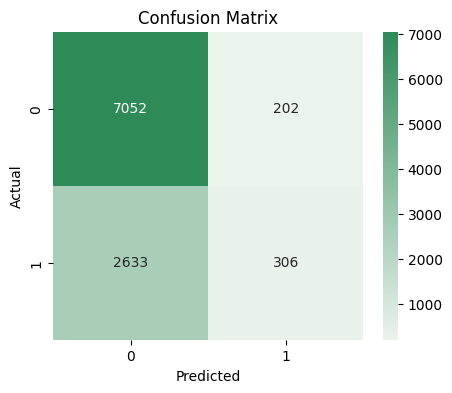

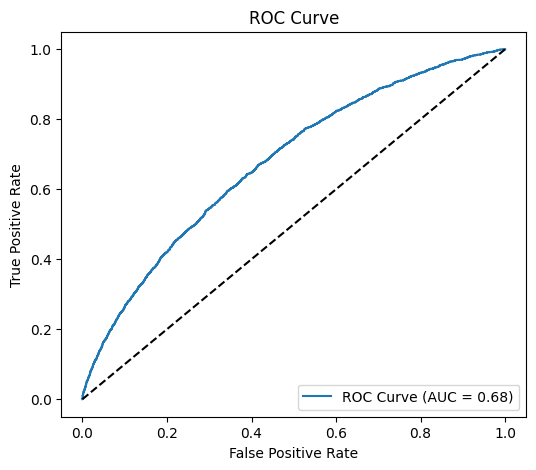

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [52]:
def xgboost_pipeline(df, target_col, model_name="xgboost_model", test_size=0.2, seed=42):
    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=test_size, random_state=seed, stratify=y
    )

    model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=seed,
        use_label_encoder=False,
        eval_metric='logloss',
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    cmap = sns.light_palette("seagreen", as_cmap=True)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.show()

    joblib.dump(model, get_path(f"models/{model_name}.joblib"))

    return model


xgboost_model = xgboost_pipeline(df=data_norm, target_col="Churn")
xgboost_model

In [53]:
df_balanced = data_norm.copy()

# Separate "Yes" and "No" rows
yes_rows = df_balanced[df_balanced["Churn"] == 1]
no_rows = df_balanced[df_balanced["Churn"] == 0]

n_samples = min(len(yes_rows), len(no_rows))

yes_sample = yes_rows.sample(n=n_samples, random_state=seed)
no_sample = no_rows.sample(n=n_samples, random_state=seed)

df_balanced = pd.concat([yes_sample, no_sample]).sample(frac=1, random_state=seed).reset_index(drop=True)
df_balanced["Churn"].value_counts()

Churn
0    14695
1    14695
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.58      0.58      2939
           1       0.57      0.56      0.57      2939

    accuracy                           0.57      5878
   macro avg       0.57      0.57      0.57      5878
weighted avg       0.57      0.57      0.57      5878



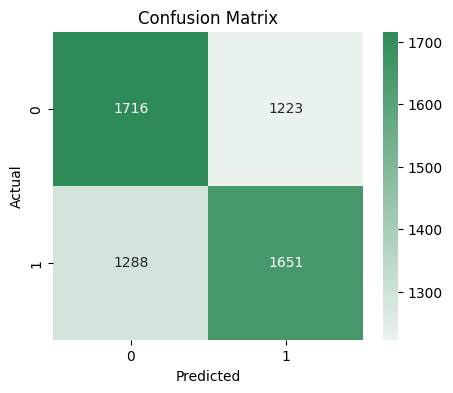

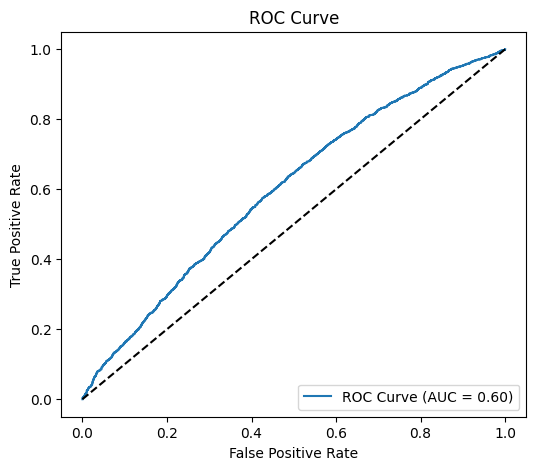

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [54]:
balanced_logistic_regression_model = logistic_regression_pipeline(df=df_balanced, target_col="Churn", model_name="logistic_regression_balanced_model")
balanced_logistic_regression_model

/Users/subin/langara/CPSC-4810/group_project/slpt/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:10:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.59      0.61      2939
           1       0.61      0.65      0.63      2939

    accuracy                           0.62      5878
   macro avg       0.62      0.62      0.62      5878
weighted avg       0.62      0.62      0.62      5878



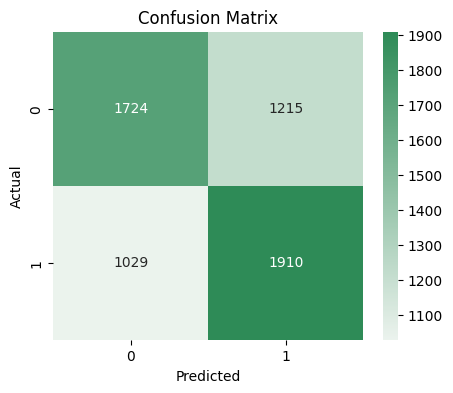

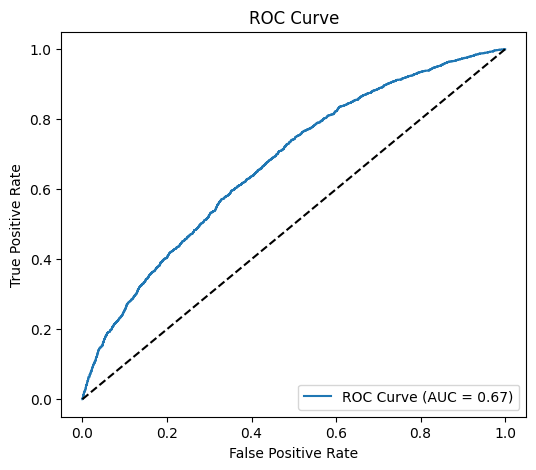

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [55]:
balanced_xgboost_model = xgboost_pipeline(df=df_balanced, target_col="Churn", model_name="xgboost_balanced_model")
balanced_xgboost_model

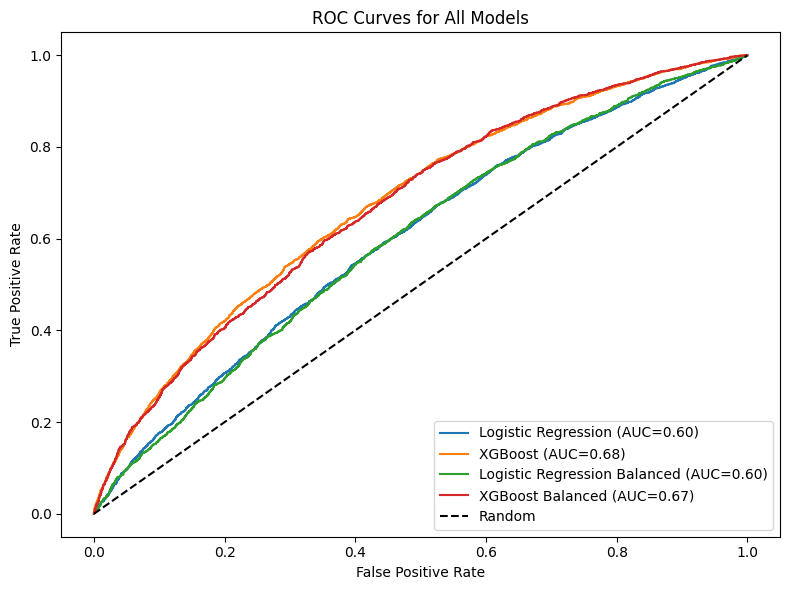

In [56]:
X_lr_train, X_lr_test, y_lr_train, y_lr_test = train_test_split(
    data_norm.drop(columns=["Churn"]),
    data_norm["Churn"],
    test_size=0.2,
    random_state=42,
    stratify=data_norm["Churn"],
)

X_bal_train, X_bal_test, y_bal_train, y_bal_test = train_test_split(
    df_balanced.drop(columns=["Churn"]),
    df_balanced["Churn"],
    test_size=0.2,
    random_state=42,
    stratify=df_balanced["Churn"],
)

plt.figure(figsize=(8, 6))

# Logistic Regression (imbalanced)
y_lr_pred = logistic_regression_model.predict_proba(X_lr_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_lr_test, y_lr_pred)
auc_lr = roc_auc_score(y_lr_test, y_lr_pred)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={auc_lr:.2f})")

# XGBoost (imbalanced)
y_xgb_pred = xgboost_model.predict_proba(X_lr_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_lr_test, y_xgb_pred)
auc_xgb = roc_auc_score(y_lr_test, y_xgb_pred)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={auc_xgb:.2f})")

# Logistic Regression (balanced)
y_bal_lr_pred = balanced_logistic_regression_model.predict_proba(X_bal_test)[:, 1]
fpr_bal_lr, tpr_bal_lr, _ = roc_curve(y_bal_test, y_bal_lr_pred)
auc_bal_lr = roc_auc_score(y_bal_test, y_bal_lr_pred)
plt.plot(
    fpr_bal_lr, tpr_bal_lr, label=f"Logistic Regression Balanced (AUC={auc_bal_lr:.2f})"
)

# XGBoost (balanced)
y_bal_xgb_pred = balanced_xgboost_model.predict_proba(X_bal_test)[:, 1]
fpr_bal_xgb, tpr_bal_xgb, _ = roc_curve(y_bal_test, y_bal_xgb_pred)
auc_bal_xgb = roc_auc_score(y_bal_test, y_bal_xgb_pred)
plt.plot(fpr_bal_xgb, tpr_bal_xgb, label=f"XGBoost Balanced (AUC={auc_bal_xgb:.2f})")

# Finalize plot
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(get_path("images/Combined_ROC_Curve.png"))
plt.show()

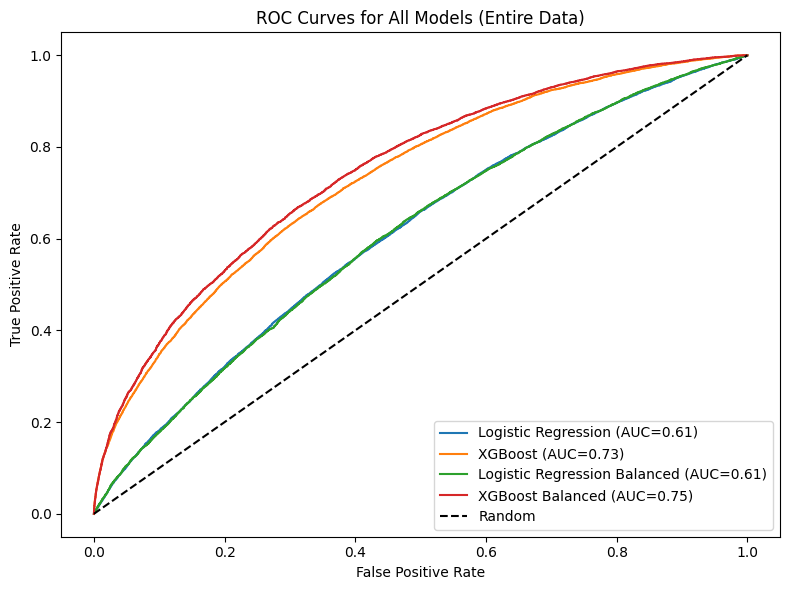

In [57]:
X = data_norm.drop(columns=["Churn"])
y = data_norm["Churn"]

X_bal = df_balanced.drop(columns=["Churn"])
y_bal = df_balanced["Churn"]

plt.figure(figsize=(8, 6))

# Logistic Regression (imbalanced)
y_lr_pred = logistic_regression_model.predict_proba(X)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y, y_lr_pred)
auc_lr = roc_auc_score(y, y_lr_pred)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={auc_lr:.2f})")

# XGBoost (imbalanced)
y_xgb_pred = xgboost_model.predict_proba(X)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y, y_xgb_pred)
auc_xgb = roc_auc_score(y, y_xgb_pred)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={auc_xgb:.2f})")

# Logistic Regression (balanced)
y_bal_lr_pred = balanced_logistic_regression_model.predict_proba(X_bal)[:, 1]
fpr_bal_lr, tpr_bal_lr, _ = roc_curve(y_bal, y_bal_lr_pred)
auc_bal_lr = roc_auc_score(y_bal, y_bal_lr_pred)
plt.plot(
    fpr_bal_lr, tpr_bal_lr, label=f"Logistic Regression Balanced (AUC={auc_bal_lr:.2f})"
)

# XGBoost (balanced)
y_bal_xgb_pred = balanced_xgboost_model.predict_proba(X_bal)[:, 1]
fpr_bal_xgb, tpr_bal_xgb, _ = roc_curve(y_bal, y_bal_xgb_pred)
auc_bal_xgb = roc_auc_score(y_bal, y_bal_xgb_pred)
plt.plot(fpr_bal_xgb, tpr_bal_xgb, label=f"XGBoost Balanced (AUC={auc_bal_xgb:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models (Entire Data)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(get_path("images/Combined_ROC_Curve_All_Data.png"))
plt.show()